In [1]:
import mne
import openneuro
import pandas as pd
import numpy as np
np.set_printoptions(threshold=np.inf)
np.set_printoptions(linewidth=np.inf)
from mne_bids import (
    BIDSPath,
    find_matching_paths,
    get_entity_vals,
    make_report,
    print_dir_tree,
    read_raw_bids,
	write_raw_bids
)

ModuleNotFoundError: No module named 'mne'

In [2]:
def _channel_mapping(channel_list):
	new_list = []

	for channel in channel_list:
		if channel == "FP1":
			new_list.append("Fp1")
		elif channel == "FP2":
			new_list.append("Fp2")
		elif channel == "CZ":
			new_list.append("Cz")
		else:
			new_list.append(channel)
	return new_list


In [3]:
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)

In [32]:
openneuro.download(dataset="ds004186", target_dir="SampleData/HBN-ECEO", include=['NDARAA075AMK'])


👋 Hello! This is openneuro-py 2024.2.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds004186 …


📁 Traversing directories for ds004186 : 0 entities [00:00, ? entities/s]

RuntimeError: Could not find path in the dataset:
- NDARAA075AMK
There were no similar filenames found in the metadata. Please check your includes.

In [4]:
TUH_patient = mne.io.read_raw_edf('SampleData/TUH/aaaaaaac_s001_t000.edf', preload=False)
_rename_channels(TUH_patient)
print(TUH_patient.info.ch_names)
TUH_patient.info["line_freq"] = 50
annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv', delimiter=',', comment='#')

onset = annotations_df['start_time']
duration = annotations_df['stop_time'] - annotations_df['start_time']
description = annotations_df['label']
ch_names = [_channel_mapping(x.split("-")) for x in annotations_df['channel'].values.tolist()]

global_annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv_bi', delimiter=',', comment='#')

onset = pd.concat([onset, global_annotations_df['start_time']])
duration = pd.concat([duration, global_annotations_df['stop_time'] - global_annotations_df['start_time']])
description = pd.concat([description, global_annotations_df['label']])
global_channel_names = [[] for x in global_annotations_df['channel'].values.tolist()]
ch_names = ch_names + global_channel_names

annotations = mne.Annotations(onset=onset, duration=duration, description=description, ch_names=ch_names)

TUH_patient.set_annotations(annotations)
montage = mne.channels.make_standard_montage("standard_1005")
TUH_patient.set_montage(montage, on_missing="ignore")
for channel in TUH_patient.info["chs"]:
	print(channel['loc'])

Extracting EDF parameters from /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/TUH/aaaaaaac_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']


/tmp/ipykernel_4161/1918410036.py:29: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)


[-0.03090259  0.11458518  0.02786657  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.0284095  0.11534631 0.02772126 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.05180904  0.0866879   0.07871409  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.05027428 0.08743839 0.07727065 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.06714872  0.02335823  0.10451068  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.06532888 0.0235731  0.10369243 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.08794078  0.00260136 -0.02686454  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[ 0.08392806  

In [ ]:
bids_path = BIDSPath(subject="aaaaaaac", task="Rest", root="SampleData/TUH-BIDS")
write_raw_bids(TUH_patient, bids_path, overwrite=True)

In [153]:
hbn_bids_path = BIDSPath(root="SampleData/HBN", session=None, datatype="eeg")
hbn_bids_path = hbn_bids_path.update(subject="NDARAC904DMU", task="RestingState", suffix="eeg")
HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)

/tmp/ipykernel_5929/2368780825.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


Reading events from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_events.tsv.
Reading channel info from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_channels.tsv.
Reading electrode coords from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_electrodes.tsv.


/tmp/ipykernel_5929/2368780825.py:3: RuntimeWarning: Unable to map the following column(s) to to MNE:
release_number: R1
ehq_total: 71.17
commercial_use: Yes
full_pheno: Yes
p_factor: -0.603
attention: -0.446
internalizing: 1.248
externalizing: 0.325
RestingState: available
DespicableMe: available
FunwithFractals: available
ThePresent: available
DiaryOfAWimpyKid: available
contrastChangeDetection_1: available
contrastChangeDetection_2: available
contrastChangeDetection_3: available
surroundSupp_1: available
surroundSupp_2: available
seqLearning6target: unavailable
seqLearning8target: available
symbolSearch: available
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


In [ ]:
tuh_bids_path = BIDSPath(root="SampleData/TUH-BIDS", session=None, datatype="eeg")
tuh_bids_path = tuh_bids_path.update(subject="aaaaaaac", task="Rest", suffix="eeg")
TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)

In [ ]:
TUH_patient.load_data()
TUH_patient.set_eeg_reference(ref_channels=['A1', 'A2'])
print(TUH_patient.info)
TUH_patient.set_eeg_reference(ref_channels=['Cz'])

In [154]:
# See Page 234 of /https://psych.colgate.edu/~bchansen/EGI_GES_INFO/NetStation_Acquisition_Technical_Manual.pdf
electrode_map = {
	'Fp1': 'E22',
	'Fp2': 'E14',
	'F7': 'E34',
	'F3': 'E25',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E46',
	'C3': 'E37',
	'Cz': 'Cz',
	'C4': 'E105',
	'T4': 'E109',
	'T5': 'E59',
	'P3': 'E53',
	'Pz': 'E62',
	'P4': 'E87',
	'T6': 'E92',
	'O1': 'E72',
	'O2': 'E77',
	'A1': 'E49',
	'A2': 'E114'
}

electrode_map2 = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
	'A1': 'E49',
	'A2': 'E113'
}

HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]

In [155]:
#TUH_patient = TUH_patient.filter(l_freq=0, h_freq=40)
HBN_patient.drop_channels(to_drop)
HBN_patient = HBN_patient.filter(l_freq=0, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 165 samples (0.330 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


In [5]:
TUH_patient.info

NameError: name 'TUH_patient' is not defined

In [126]:
HBN_patient.info

<Info | 10 non-empty values
 bads: []
 ch_names: E9, E11, E22, E24, E33, E36, E45, E52, E58, E62, E70, E83, E92, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 129 items (129 EEG)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 40.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
 subject_info: 2 items (dict)
>

In [22]:
TUH_patient.get_montage().plot(show_names=True)

NameError: name 'TUH_patient' is not defined

In [12]:
for channel in HBN_patient.info["chs"]:
	print(channel['loc'])

[ 0.05787678  0.05520863 -0.02577469  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.05291805 0.06709098 0.00307435 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.03864122 0.07634241 0.0306777  0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.02868838 0.07145709 0.04989565 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.0147934  0.05686621 0.06812878 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.         0.0380677  0.07891305 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.012238    0.01558864  0.08440439  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[ 0.04221902  0.07998817 -0.0135479   

In [156]:
ch_pos = {}

for channel in HBN_patient.info["chs"]:
	ch_pos[channel['ch_name']] = channel['loc'][0:3]

print(ch_pos)

montage = mne.channels.make_dig_montage(ch_pos, coord_frame='head')

HBN_patient.set_montage(montage)

{'E9': array([ 0.00888482, -0.00269541,  0.00108831]), 'E11': array([ 0.00796265, -0.        ,  0.00504472]), 'E22': array([0.00888482, 0.00269541, 0.00108831]), 'E24': array([0.00602116, 0.00445939, 0.00436532]), 'E33': array([ 0.00412725,  0.00639909, -0.00035685]), 'E36': array([0.00028495, 0.00547913, 0.00638333]), 'E45': array([-0.00186624,  0.00730462, -0.00062918]), 'E52': array([-0.00449482,  0.00583124,  0.00495535]), 'E58': array([-5.755782e-03,  6.034747e-03,  5.184300e-05]), 'E62': array([-0.00667669, -0.        ,  0.00646521]), 'E70': array([-0.00860797,  0.00273884,  0.00023937]), 'E83': array([-0.00860797, -0.00273884,  0.00023937]), 'E92': array([-0.00449482, -0.00583124,  0.00495535]), 'E96': array([-5.755782e-03, -6.034747e-03,  5.184300e-05]), 'E104': array([ 0.00028495, -0.00547913,  0.00638333]), 'E108': array([-0.00186624, -0.00730462, -0.00062918]), 'E122': array([ 0.00412725, -0.00639909, -0.00035685]), 'E124': array([ 0.00602116, -0.00445939,  0.00436532]), 'Cz

<RawEEGLAB | sub-NDARAC904DMU_task-RestingState_eeg.set, 19 x 201737 (403.5 s), ~29.3 MB, data loaded>

In [171]:
for k, v in HBN_patient.info.items():
	print(k, v)

acq_pars None
acq_stim None
ctf_head_t None
description None
dev_ctf_t None
dig [<DigPoint |        LPA : (-8.6, 0.0, 0.0) mm       : head frame>, <DigPoint |     Nasion : (0.0, 8.6, 0.0) mm        : head frame>, <DigPoint |        RPA : (8.6, 0.0, 0.0) mm        : head frame>, <DigPoint |     EEG #1 : (8.9, -2.7, 1.1) mm       : head frame>, <DigPoint |     EEG #2 : (8.0, -0.0, 5.0) mm       : head frame>, <DigPoint |     EEG #3 : (8.9, 2.7, 1.1) mm        : head frame>, <DigPoint |     EEG #4 : (6.0, 4.5, 4.4) mm        : head frame>, <DigPoint |     EEG #5 : (4.1, 6.4, -0.4) mm       : head frame>, <DigPoint |     EEG #6 : (0.3, 5.5, 6.4) mm        : head frame>, <DigPoint |     EEG #7 : (-1.9, 7.3, -0.6) mm      : head frame>, <DigPoint |     EEG #8 : (-4.5, 5.8, 5.0) mm       : head frame>, <DigPoint |     EEG #9 : (-5.8, 6.0, 0.1) mm       : head frame>, <DigPoint |    EEG #10 : (-6.7, -0.0, 6.5) mm      : head frame>, <DigPoint |    EEG #11 : (-8.6, 2.7, 0.2) mm       : head fra

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>
{'ch_pos': OrderedDict([('E9', array([ 0.0888482 , -0.02695406,  0.01088308])), ('E11', array([0.07962647, 0.        , 0.05044718])), ('E22', array([0.0888482 , 0.02695406, 0.01088308])), ('E24', array([0.0602116 , 0.04459387, 0.04365321])), ('E33', array([ 0.04127249,  0.06399087, -0.00356852])), ('E36', array([0.00284949, 0.0547913 , 0.06383328])), ('E45', array([-0.01866238,  0.07304625, -0.00629182])), ('E52', array([-0.04494822,  0.05831241,  0.04955348])), ('E58', array([-0.05755782,  0.06034747,  0.00051843])), ('E62', array([-0.06676694,  0.        ,  0.06465208])), ('E70', array([-0.08607967,  0.02738838,  0.00239368])), ('E83', array([-0.08607967, -0.02738838,  0.00239368])), ('E92', array([-0.04494822, -0.05831241,  0.04955348])), ('E96', array([-0.05755782, -0.06034747,  0.00051843])), ('E104', array([ 0.00284949, -0.0547913 ,  0.06383328])), ('E108', array([-0.01866238, -0.07304625, -0.00629182])), ('E12

/tmp/ipykernel_5929/470286117.py:19: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  hbn_montage.plot(show_names=True, sphere=0.095)


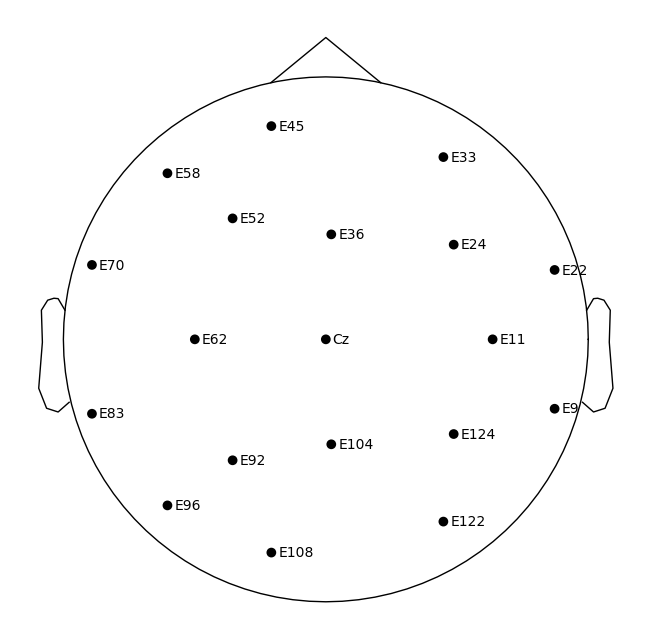

{'ch_pos': OrderedDict([('E9', array([0.02695406, 0.0888482 , 0.01088308])), ('E11', array([0.        , 0.07962647, 0.05044718])), ('E22', array([-0.02695406,  0.0888482 ,  0.01088308])), ('E24', array([-0.04459387,  0.0602116 ,  0.04365321])), ('E33', array([-0.06399087,  0.04127249, -0.00356852])), ('E36', array([-0.0547913 ,  0.00284949,  0.06383328])), ('E45', array([-0.07304625, -0.01866238, -0.00629182])), ('E52', array([-0.05831241, -0.04494822,  0.04955348])), ('E58', array([-0.06034747, -0.05755782,  0.00051843])), ('E62', array([ 0.        , -0.06676694,  0.06465208])), ('E70', array([-0.02738838, -0.08607967,  0.00239368])), ('E83', array([ 0.02738838, -0.08607967,  0.00239368])), ('E92', array([ 0.05831241, -0.04494822,  0.04955348])), ('E96', array([ 0.06034747, -0.05755782,  0.00051843])), ('E104', array([0.0547913 , 0.00284949, 0.06383328])), ('E108', array([ 0.07304625, -0.01866238, -0.00629182])), ('E122', array([ 0.06399087,  0.04127249, -0.00356852])), ('E124', array

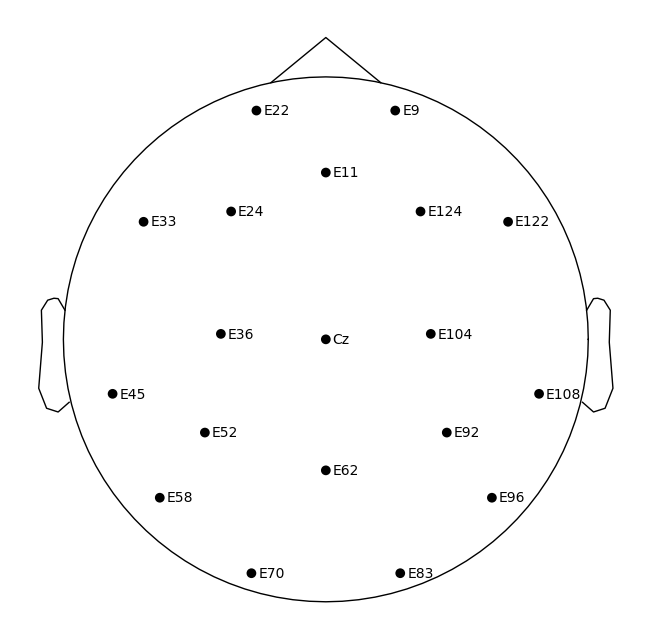

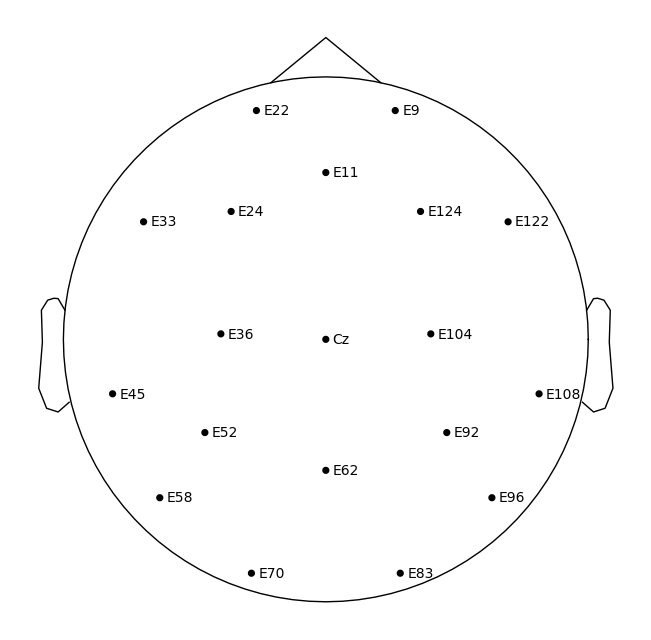

In [192]:
# Define the transformation matrix for 90 degrees counterclockwise rotation
transformation_matrix = np.array([[0, -1, 0, 0],
								  [1, 0, 0, 0],
								  [0, 0, 1, 0],
								  [0, 0, 0, 1]])

transformation_matrix2 = np.array([[10, 0, 0, 0],
								  [0, 10, 0, 0],
								  [0, 0, 10, 0],
								  [0, 0, 0, 10]])


# Get the current montage
hbn_montage = HBN_patient.get_montage()
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix2))
print(hbn_montage)
print(hbn_montage.get_positions())
hbn_montage.remove_fiducials()
hbn_montage.plot(show_names=True, sphere=0.095)
# Apply the transformation
hbn_montage.apply_trans(mne.transforms.Transform(fro='unknown', to='head', trans=transformation_matrix))

# Print the new positions
print(hbn_montage.get_positions())

# Plot the new montage
hbn_montage.plot(show_names=True, sphere=0.095)

# Undo fiducial transformation

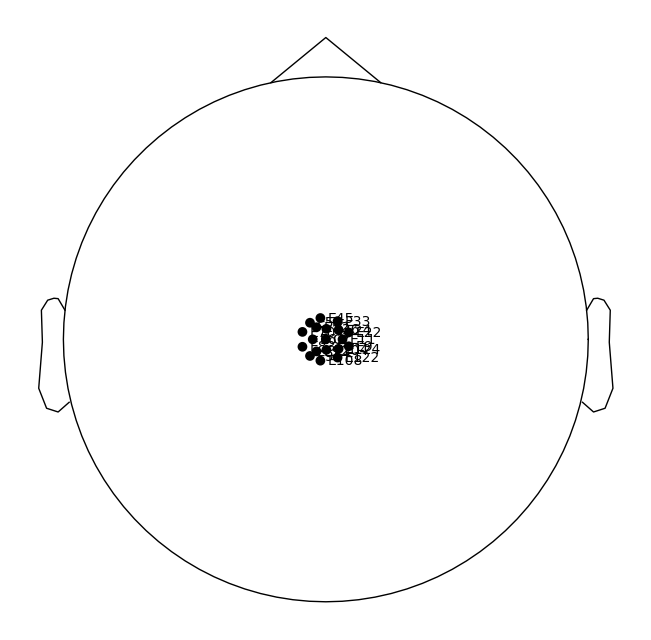

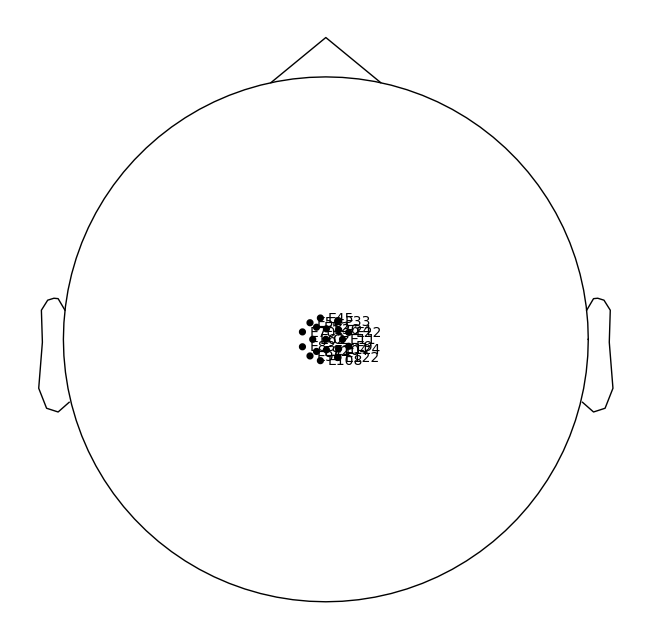

In [178]:
HBN_patient.get_montage().plot(show_names=True)

{'ch_pos': OrderedDict([('E9', array([ 0.00888482, -0.00269541,  0.00108831])), ('E11', array([ 0.00796265, -0.        ,  0.00504472])), ('E22', array([0.00888482, 0.00269541, 0.00108831])), ('E24', array([0.00602116, 0.00445939, 0.00436532])), ('E33', array([ 0.00412725,  0.00639909, -0.00035685])), ('E36', array([0.00028495, 0.00547913, 0.00638333])), ('E45', array([-0.00186624,  0.00730462, -0.00062918])), ('E52', array([-0.00449482,  0.00583124,  0.00495535])), ('E58', array([-5.755782e-03,  6.034747e-03,  5.184300e-05])), ('E62', array([-0.00667669, -0.        ,  0.00646521])), ('E70', array([-0.00860797,  0.00273884,  0.00023937])), ('E83', array([-0.00860797, -0.00273884,  0.00023937])), ('E92', array([-0.00449482, -0.00583124,  0.00495535])), ('E96', array([-5.755782e-03, -6.034747e-03,  5.184300e-05])), ('E104', array([ 0.00028495, -0.00547913,  0.00638333])), ('E108', array([-0.00186624, -0.00730462, -0.00062918])), ('E122', array([ 0.00412725, -0.00639909, -0.00035685])), ('

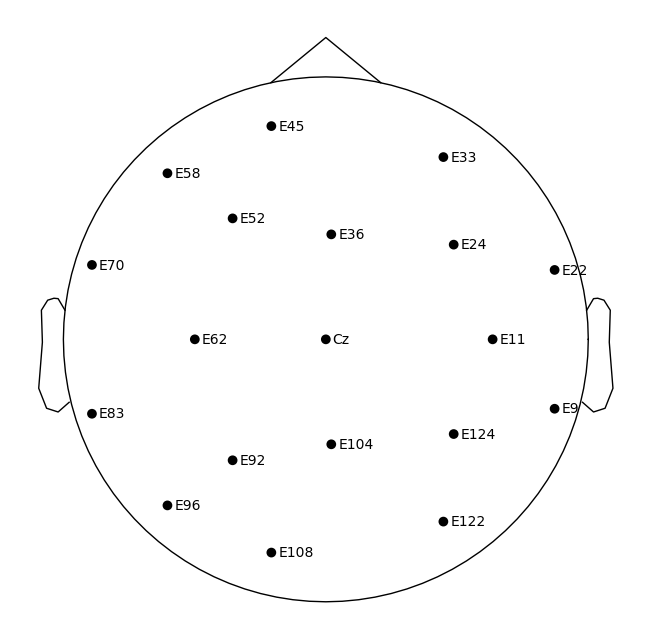

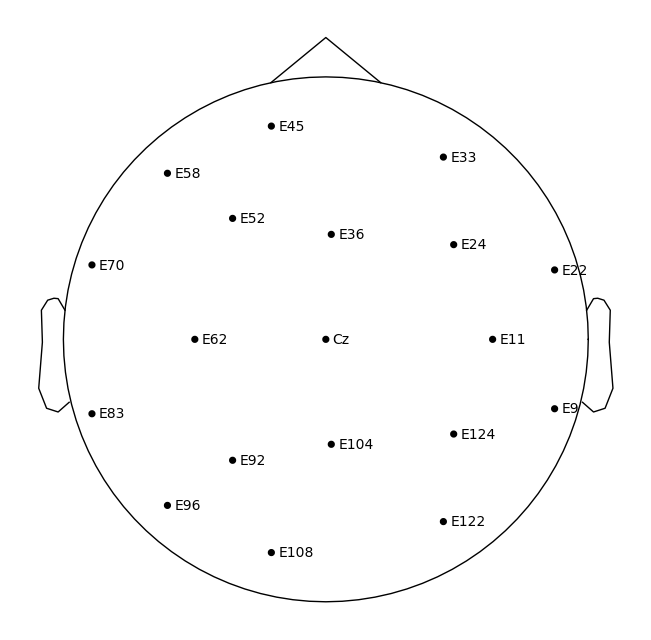

In [175]:
transformation_matrix = np.asarray([[0, -10, 0, 0], [10, 0, 0, 0], [0, 0, 10, 0], [0, 0, 0, 1]])
hbn_montage = HBN_patient.get_montage()
print(hbn_montage.get_positions())
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix))
print(hbn_montage.get_positions())
hbn_montage.plot(show_names=True, sphere=0.095)

Using matplotlib as 2D backend.


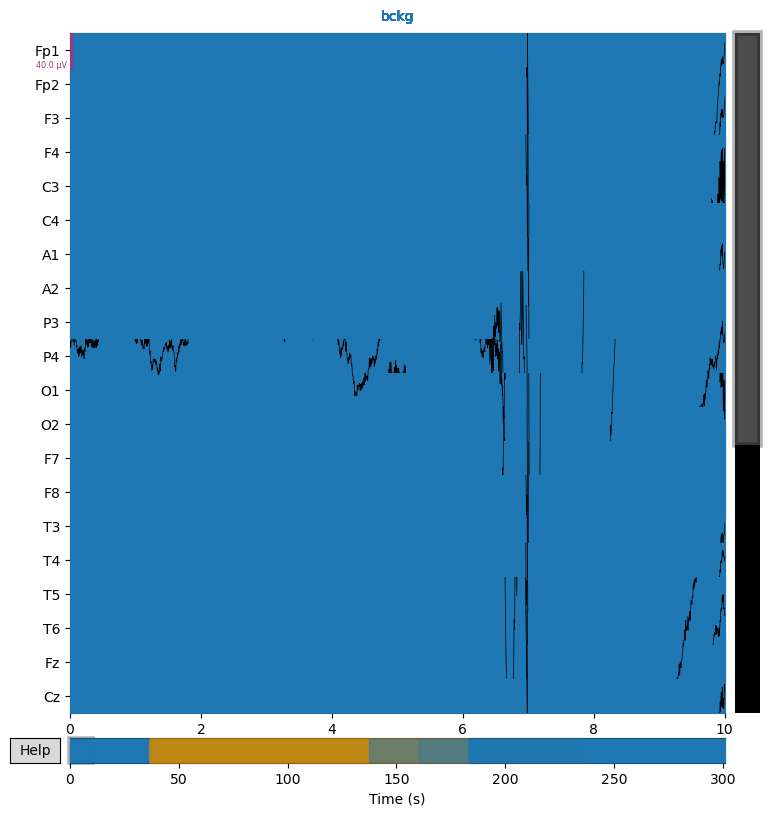

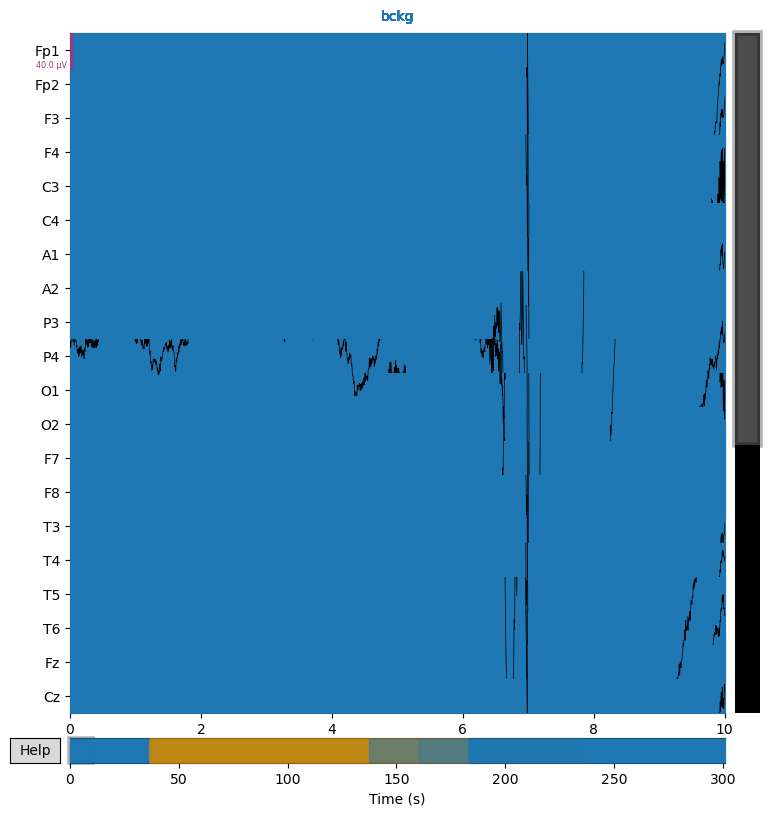

In [9]:
mne.viz.set_browser_backend("matplotlib")
TUH_patient.plot()

In [ ]:
print(TUH_patient.annotations)

In [9]:
TUH_patient = mne.io.read_raw_edf('/home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf', preload=False)
TUH_patient.info

Extracting EDF parameters from /home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 31 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2015-01-01 00:00:00 UTC
 nchan: 31
 projs: []
 sfreq: 256.0 Hz
 subject_info: 3 items (dict)
>

In [13]:
print(TUH_patient.info['meas_date'])
print(TUH_patient.annotations)
print(TUH_patient.get_montage())
print(TUH_patient._raw_extras[0]['age'])

2015-01-01 00:00:00+00:00
<Annotations | 0 segments>
None


KeyError: 'age'

In [14]:
from edfio import read_edf


edf = read_edf('/home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf')


In [18]:
print(edf.patient)
print(edf.recording)

'aaaaaaaa M 01-JAN-0000 aaaaaaaa Age:37'
Recording(startdate=datetime.date(2015, 1, 1), hospital_administration_code='aaaaaaaa_s001', investigator_technician_code='XXX', equipment_code='#', additional=())


In [1]:
import os
from tqdm import tqdm
import mne
from mne_bids import BIDSPath, read_raw_bids, write_raw_bids
import pandas as pd
import numpy as np
import os, argparse
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings


CHANNELS_TO_KEEP = {
	"Fp1",
	"Fp2",
	"F3",
	"F4",
	"C3",
	"C4",
	"A1",
	"A2",
	"P3",
	"P4",
	"O1",
	"O2",
	"F7",
	"F8",
	"T3",
	"T4",
	"T5",
	"T6",
	"Fz",
	"Cz",
	"Pz",
}

print(len(CHANNELS_TO_KEEP))
def process_file(args, subfolder, subject, session, montage_layout, file_token, failed_files):
        if file_token.endswith(".edf"):
            _convertEDFtoBIDS(args, subfolder, subject, session, montage_layout, file_token, failed_files)
        else:
            print("-----------------------------------", file_token)

def convertTUHtoBIDS(args):
	'''
	Converts TUH EEG data to BIDS format.
	'''

	# Collect all files to be processed
	files_to_process = []
	for subfolder in tqdm(os.listdir(args.input_dir)):
		for subject in os.listdir(os.path.join(args.input_dir, subfolder)):
			subject_dir = os.path.join(args.input_dir, subfolder, subject)
			for session in os.listdir(subject_dir):
				for montage_layout in os.listdir(os.path.join(subject_dir, session)):
					for file_token in os.listdir(os.path.join(subject_dir, session, montage_layout)):
						files_to_process.append((args, subfolder, subject, session, montage_layout, file_token))
                            
	return files_to_process
                            
    
def _convertEDFtoBIDS(args, subfolder, subject, session, montage_layout, file_token, failed_files):
	'''
	Converts an EDF file to BIDS format.
	'''
	filepath = os.path.join(args.input_dir, subfolder, subject, session, montage_layout, file_token)
	raw = mne.io.read_raw_edf(filepath, preload=False, verbose=False)
	_rename_channels(raw)

	to_drop = [ch for ch in raw.ch_names if ch not in CHANNELS_TO_KEEP]

	try:
		raw.drop_channels(to_drop)
	except ValueError as e:
		failed_files.append((subject, session, montage_layout, file_token))
		return

	'''
	BIDS Format requires line frequency to be specified.
	Line frequency is the frequency of the power line in the country where the data was recorded.
	For the United States, the line frequency is (typically) 60 Hz.	
	'''
	raw.info["line_freq"] = 60
	raw.set_montage("standard_1005", on_missing="ignore")
	try: 
		assert len(raw.info["ch_names"]) == 21 or len(raw.info["ch_names"]) == 19, f"Expected 19 or 21 channels, got {len(raw.info['ch_names'])} channels."
	except AssertionError as e:
		failed_files.append((subject, session, montage_layout, file_token))
		return
		
	'''
	bids_path = BIDSPath(subject=subject, session=session.replace("_", ""), processing=montage_layout.replace("_", ""),
					     recording=file_token[:-4].split("_")[-1], task="Rest", root=args.output_dir)
                              
    '''
     
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")

	# Changed this line
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)
            
# Ignore a specific warning category
warnings.filterwarnings("ignore", category=RuntimeWarning, module="mne")


21


In [2]:
parser = argparse.ArgumentParser()

default_output_dir = "/home/azureuser/mycontainer/TUH-BIDS"
parser.add_argument(
	"--input_dir", type=str, help="Input directory", default="/home/azureuser/mycontainer/edf"
)
parser.add_argument(
	"--output_dir", type=str, help="Output directory", default=default_output_dir
)

#Path(default_output_dir).mkdir(parents=True, exist_ok=True)

args, unknown = parser.parse_known_args()
files_to_process = convertTUHtoBIDS(args)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [09:37<00:00,  3.83s/it]


In [4]:
print(f"Processing {len(files_to_process)} files...")

Processing 69652 files...


In [8]:
print(files_to_process[29084 - 1])

(Namespace(input_dir='/home/azureuser/mycontainer/edf', output_dir='/home/azureuser/mycontainer/TUH-BIDS'), '082', 'aaaaamhd', 's009_2015', '01_tcp_ar', 'aaaaamhd_s009_t007.edf')


In [4]:

failed_files = []

In [ ]:
30591

In [42]:
for idx in tqdm(range(30580, 30599)):
	process_file(*files_to_process[idx], failed_files)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:09<00:00,  1.94it/s]


In [5]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_file, *file_args, failed_files) for file_args in files_to_process[39184:]]
    for future in tqdm(as_completed(futures), total=len(futures)):
        future.result()  # To raise exceptions if any

Setting channel info structure...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30468/30468 [31:02<00:00, 16.36it/s]


In [6]:
print(len(failed_files))
print(failed_files)

25
[('aaaaapks', 's013_2014', '03_tcp_ar_a', 'aaaaapks_s013_t002.edf'), ('aaaaaqzw', 's002_2014', '01_tcp_ar', 'aaaaaqzw_s002_t001.edf'), ('aaaaaria', 's001_2014', '01_tcp_ar', 'aaaaaria_s001_t000.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t001.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t004.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t002.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t003.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t005.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t006.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t007.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t010.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t012.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t011.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t009.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaar

In [7]:
pd.DataFrame(failed_files, columns=["subject", "session", "montage_layout", "file_token"]).to_csv("failed_files_2.csv", index=False)

In [35]:
hbn_bids_path = BIDSPath(root="SampleData/HBN-ECEO", session=None, datatype="eeg")
hbn_bids_path = hbn_bids_path.update(subject="NDARZZ993CEV", task="EC", run=1, suffix="eeg")
HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EC_run-1_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EC_run-1_channels.tsv.


/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EC_run-1.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EC_run-1_electrodes.tsv.


/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

In [43]:
HBN_patient.info

ch_pos = {}

for channel in HBN_patient.info["chs"]:
	ch_pos[channel['ch_name']] = channel['loc'][0:3]

montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')
print(montage)

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 129 channels>


In [37]:
montage = HBN_patient.get_montage()
print(montage)

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 0 channels>


In [7]:
print(HBN_patient.n_times, HBN_patient.info['sfreq'], HBN_patient.get_data().shape, HBN_patient.get_data().shape[1] / HBN_patient.info['sfreq'])

19998 500.0 (129, 19998) 39.996


In [57]:
HBN_patient_runs = []
for run in range(1, 6):
	hbn_bids_path = BIDSPath(root="SampleData/HBN-ECEO", session=None, datatype="eeg")
	hbn_bids_path = hbn_bids_path.update(subject="NDARZZ993CEV", task="EO", run=run, suffix="eeg")
	HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
	HBN_patient_runs.append(HBN_patient)

HBN_EC = mne.concatenate_raws(HBN_patient_runs)

print(HBN_EC.n_times, HBN_EC.info['sfreq'], HBN_EC.get_data().shape, HBN_EC.get_data().shape[1] / HBN_EC.info['sfreq'])



Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_channels.tsv.
Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_electrodes.tsv.


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-1.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_eeg.fdt


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_channels.tsv.


...

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-4_electrodes.tsv.
Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_eeg.fdt


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_channels.tsv.
Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_electrodes.tsv.


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E4" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E

49990 500.0 (129, 49990) 99.98


In [4]:
HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_EC.drop_channels(to_drop)

NameError: name 'HBN_EC' is not defined

In [61]:
ch_pos = {}

for channel in HBN_EC.info["chs"]:
	ch_pos[channel['ch_name']] = channel['loc'][0:3]

montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')

print(ch_pos)

{'E9': array([0.02695406, 0.0888482 , 0.01088308]), 'E11': array([0.        , 0.07962647, 0.05044718]), 'E22': array([-0.02695406,  0.0888482 ,  0.01088308]), 'E24': array([-0.04459387,  0.0602116 ,  0.04365321]), 'E33': array([-0.06399087,  0.04127249, -0.00356852]), 'E36': array([-0.0547913 ,  0.00284949,  0.06383328]), 'E45': array([-0.07304625, -0.01866238, -0.00629182]), 'E52': array([-0.05831241, -0.04494822,  0.04955348]), 'E58': array([-0.06034747, -0.05755782,  0.00051843]), 'E62': array([ 8.17659198e-18, -6.67669403e-02,  6.46520826e-02]), 'E70': array([-0.02738838, -0.08607967,  0.00239368]), 'E83': array([ 0.02738838, -0.08607967,  0.00239368]), 'E92': array([ 0.05831241, -0.04494822,  0.04955348]), 'E96': array([ 0.06034747, -0.05755782,  0.00051843]), 'E104': array([0.0547913 , 0.00284949, 0.06383328]), 'E108': array([ 0.07304625, -0.01866238, -0.00629182]), 'E122': array([ 0.06399087,  0.04127249, -0.00356852]), 'E124': array([0.04459387, 0.0602116 , 0.04365321]), 'Cz': 

In [63]:
# Set all channels to be EEG channels
mapping = {ch: 'eeg' for ch in HBN_EC.ch_names}
HBN_EC.set_channel_types(mapping)

/tmp/ipykernel_5929/2200048278.py:3: RuntimeWarning: The unit for channel(s) Cz, E104, E108, E11, E122, E124, E22, E24, E33, E36, E45, E52, E58, E62, E70, E83, E9, E92, E96 has changed from NA to V.
  HBN_EC.set_channel_types(mapping)


<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~25 kB, data not loaded>

In [64]:
HBN_EC.set_montage(montage, match_case=False)

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~33 kB, data not loaded>

In [65]:
for channel in HBN_EC.info["chs"]:
	print(channel['loc'])

[0.02695406 0.0888482  0.01088308 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.         0.07962647 0.05044718 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.02695406  0.0888482   0.01088308  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.04459387  0.0602116   0.04365321  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.06399087  0.04127249 -0.00356852  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.0547913   0.00284949  0.06383328  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.07304625 -0.01866238 -0.00629182  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-

In [66]:
HBN_EC.set_montage(montage)

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~33 kB, data not loaded>

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>
{'ch_pos': OrderedDict([('E9', array([-0.0888482 ,  0.02695406,  0.01088308])), ('E11', array([-0.07962647,  0.        ,  0.05044718])), ('E22', array([-0.0888482 , -0.02695406,  0.01088308])), ('E24', array([-0.0602116 , -0.04459387,  0.04365321])), ('E33', array([-0.04127249, -0.06399087, -0.00356852])), ('E36', array([-0.00284949, -0.0547913 ,  0.06383328])), ('E45', array([ 0.01866238, -0.07304625, -0.00629182])), ('E52', array([ 0.04494822, -0.05831241,  0.04955348])), ('E58', array([ 0.05755782, -0.06034747,  0.00051843])), ('E62', array([6.67669403e-02, 8.17659198e-18, 6.46520826e-02])), ('E70', array([ 0.08607967, -0.02738838,  0.00239368])), ('E83', array([0.08607967, 0.02738838, 0.00239368])), ('E92', array([0.04494822, 0.05831241, 0.04955348])), ('E96', array([0.05755782, 0.06034747, 0.00051843])), ('E104', array([-0.00284949,  0.0547913 ,  0.06383328])), ('E108', array([ 0.01866238,  0.07304625, -0.006291

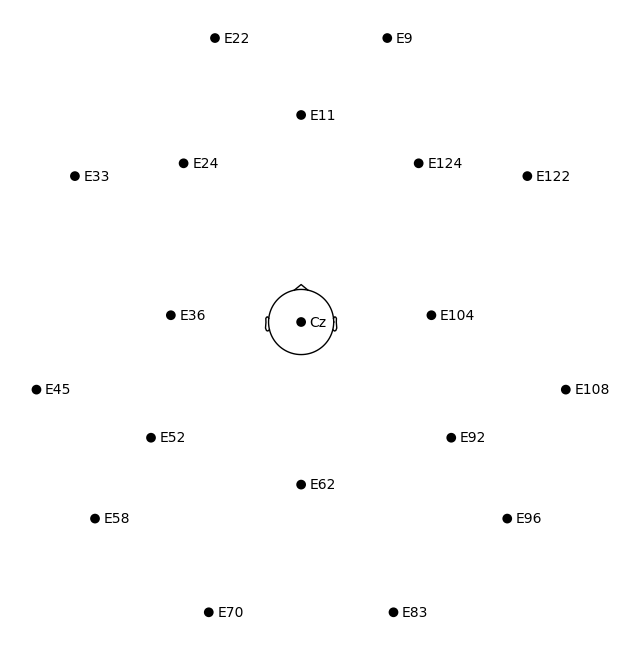

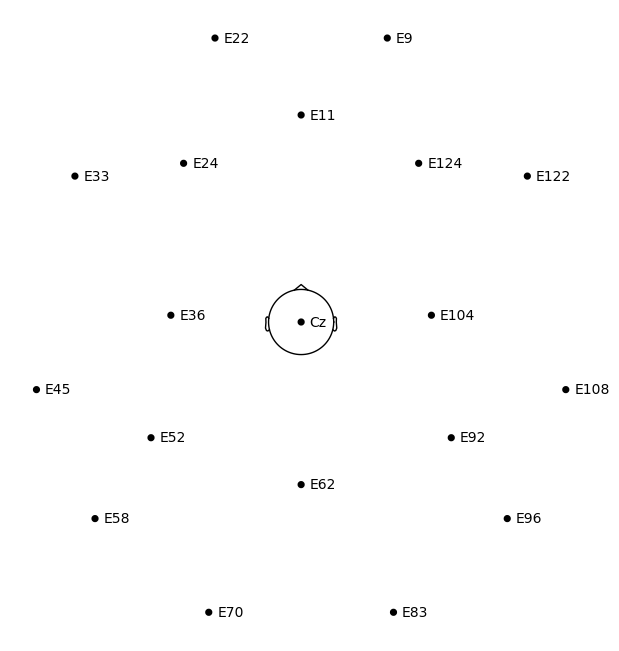

In [67]:
transformation_matrix = np.asarray([[0, -1, 0, 0], [1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
hbn_montage = HBN_EC.get_montage()
print(HBN_EC.get_montage())
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix))
print(hbn_montage.get_positions())
hbn_montage.plot(show_names=True, sphere=0.0095)

In [115]:
HBN_patient_runs = []
for run in range(1, 6):
	hbn_bids_path = BIDSPath(root="SampleData/HBN-ECEO", session=None, datatype="eeg")
	hbn_bids_path = hbn_bids_path.update(subject="NDARZZ993CEV", task="EO", run=run, suffix="eeg")
	HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
	HBN_patient_runs.append(HBN_patient)

HBN_EC = mne.concatenate_raws(HBN_patient_runs)

# Set all channels to be EEG channels
mapping = {ch: 'eeg' for ch in HBN_EC.ch_names}
HBN_EC.set_channel_types(mapping)

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_channels.tsv.
Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_electrodes.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-1.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_channels.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Unable to map the following column(s) to to MNE:
release: 9
gender: 1
handedness: -73.3400000000
commercial_use: Yes
full_pheno: Yes
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-2.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_electrodes.tsv.
Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-3_eeg.fdt


...

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_channels.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Unable to map the following column(s) to to MNE:
release: 9
gender: 1
handedness: -73.3400000000
commercial_use: Yes
full_pheno: Yes
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-5.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_electrodes.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 129 x 49990 (100.0 s), ~125 kB, data not loaded>

In [118]:
HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}

HBN_ELECTRODE_MAP_2 = {
	'Fp1': 'E37',
	'Fp2': 'E18',
	'F7': 'E47',
	'F3': 'E36',
	'Fz': 'E21',
	'F4': 'E224',
	'F8': 'E2',
	'T3': 'E69',
	'C3': 'E59',
	'Cz': 'Cz',
	'C4': 'E183',
	'T4': 'E202',
	'T5': 'E96',
	'P3': 'E87',
	'Pz': 'E101',
	'P4': 'E153',
	'T6': 'E270',
	'O1': 'E116',
	'O2': 'E150',
	'A1': 'E49',
	'A2': 'E113'
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_EC.drop_channels(to_drop)
print(HBN_EC.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 19 channels>


In [117]:
print(len(HBN_ELECTRODE_MAP_2))

21


In [147]:
ch_pos = {}

for channel in HBN_EC.info["chs"]:

	ch_pos[channel['ch_name']] = channel['loc'][0:3]

montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')

HBN_EC.set_montage(montage)

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~33 kB, data not loaded>

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>
{'ch_pos': OrderedDict([('E9', array([0.02695406, 0.0888482 , 0.01088308])), ('E11', array([0.        , 0.07962647, 0.05044718])), ('E22', array([-0.02695406,  0.0888482 ,  0.01088308])), ('E24', array([-0.04459387,  0.0602116 ,  0.04365321])), ('E33', array([-0.06399087,  0.04127249, -0.00356852])), ('E36', array([-0.0547913 ,  0.00284949,  0.06383328])), ('E45', array([-0.07304625, -0.01866238, -0.00629182])), ('E52', array([-0.05831241, -0.04494822,  0.04955348])), ('E58', array([-0.06034747, -0.05755782,  0.00051843])), ('E62', array([ 8.17659198e-18, -6.67669403e-02,  6.46520826e-02])), ('E70', array([-0.02738838, -0.08607967,  0.00239368])), ('E83', array([ 0.02738838, -0.08607967,  0.00239368])), ('E92', array([ 0.05831241, -0.04494822,  0.04955348])), ('E96', array([ 0.06034747, -0.05755782,  0.00051843])), ('E104', array([0.0547913 , 0.00284949, 0.06383328])), ('E108', array([ 0.07304625, -0.01866238, -0.006

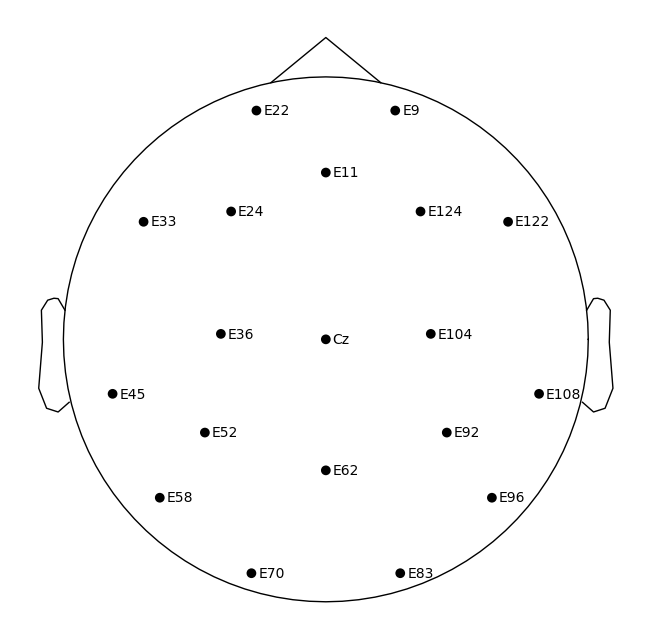

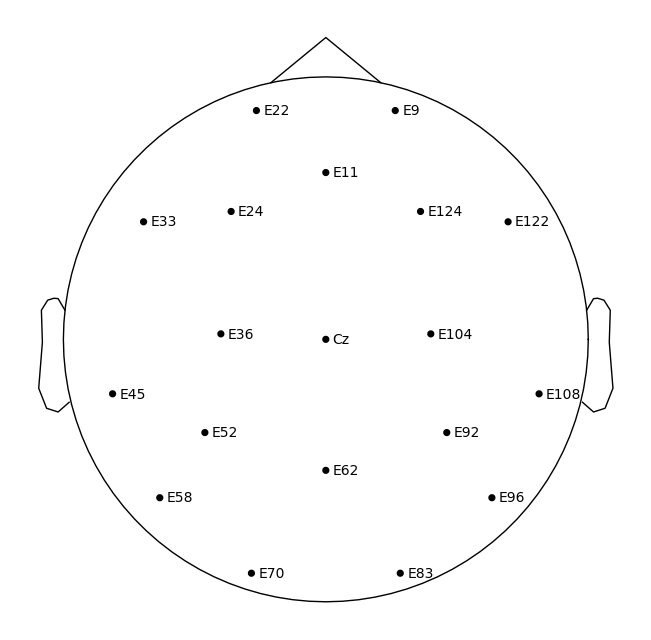

In [148]:
transformation_matrix = np.asarray([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
hbn_montage = HBN_EC.get_montage()
print(HBN_EC.get_montage())
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix))
print(hbn_montage.get_positions())
hbn_montage.plot(show_names=True, sphere=0.095)

In [149]:
for k, v in HBN_EC.info.items():
	print(k, v)

acq_pars None
acq_stim None
ctf_head_t None
description None
dev_ctf_t None
dig [<DigPoint |        LPA : (-86.0, 0.0, 0.0) mm      : head frame>, <DigPoint |     Nasion : (0.0, 86.0, 0.0) mm       : head frame>, <DigPoint |        RPA : (86.0, 0.0, 0.0) mm       : head frame>, <DigPoint |     EEG #1 : (27.0, 88.8, 10.9) mm     : head frame>, <DigPoint |     EEG #2 : (0.0, 79.6, 50.4) mm      : head frame>, <DigPoint |     EEG #3 : (-27.0, 88.8, 10.9) mm    : head frame>, <DigPoint |     EEG #4 : (-44.6, 60.2, 43.7) mm    : head frame>, <DigPoint |     EEG #5 : (-64.0, 41.3, -3.6) mm    : head frame>, <DigPoint |     EEG #6 : (-54.8, 2.8, 63.8) mm     : head frame>, <DigPoint |     EEG #7 : (-73.0, -18.7, -6.3) mm   : head frame>, <DigPoint |     EEG #8 : (-58.3, -44.9, 49.6) mm   : head frame>, <DigPoint |     EEG #9 : (-60.3, -57.6, 0.5) mm    : head frame>, <DigPoint |    EEG #10 : (0.0, -66.8, 64.7) mm     : head frame>, <DigPoint |    EEG #11 : (-27.4, -86.1, 2.4) mm    : head fra

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
from Preprocessing.preprocessingPipeline import simplePipeline

In [14]:
bids_path = BIDSPath(root="~/mycontainer/ds004186-download", subject="NDARAA075AMK", datatype="eeg", suffix="eeg", extension=".set", task="EC")
ELECTRODES = [f'E{i}' for i in range(1, 129)]
TO_DROP = [electrode for electrode in ELECTRODES if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_ELECTRODE_MAP_REVERSED = dict((v,k) for k,v in HBN_ELECTRODE_MAP.items())
task_all_data = []
runs = [1, 2, 3, 4, 5]
indices = None
for run in runs:
	try:
		bids_path.update(run=run)		
		raw = read_raw_bids(bids_path, extra_params={'preload':True}, verbose=False)
		raw.drop_channels(TO_DROP)
		mapping = {ch: 'eeg' for ch in raw.ch_names}
		raw.set_channel_types(mapping)
		raw.rename_channels(HBN_ELECTRODE_MAP_REVERSED)
		if indices is None:
			indices = raw.ch_names
		task_all_data.append(raw)

	except Exception as e:
		print(e)
concatenated_raw = mne.concatenate_raws(task_all_data)

mapping = {ch: 'eeg' for ch in concatenated_raw.ch_names}
concatenated_raw.set_channel_types(mapping)

annotations_to_drop = [i for i in range(len(concatenated_raw.annotations))]
concatenated_raw.annotations.delete(annotations_to_drop)

epochs = simplePipeline(concatenated_raw)

Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 3 events and 30000 original time points ...
0 bad epochs dropped
((), (), ())


In [11]:
print(concatenated_raw.annotations)
print(len(concatenated_raw.annotations))

<Annotations | 8 segments: BAD boundary (4), EDGE boundary (4)>
8


In [10]:
for annotation in concatenated_raw.annotations:
	print(annotation)

OrderedDict([('onset', 39.996), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 39.996), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])
OrderedDict([('onset', 79.992), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 79.992), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])
OrderedDict([('onset', 119.988), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 119.988), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])
OrderedDict([('onset', 159.984), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 159.984), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])


In [17]:
bids_path = BIDSPath(root="~/mycontainer/ds004186-download", datatype="eeg", suffix="eeg", extension=".set")
subjects = sorted(set([bp.subject for bp in bids_path.match()]))

KeyboardInterrupt: 

In [1]:
subfolders = [f.path for f in os.scandir("/home/azureuser/mycontainer/ds004186-download") if f.is_dir() ]
print(len(subfolders))
subfolders = subfolders[2:]
print(len(subfolders))
print(subfolders[0:5])

2953
2951
['/home/azureuser/mycontainer/ds004186-download/sub-NDARAA075AMK', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA117NEJ', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA396TWZ', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA773LUW', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA947ZG5']


In [2]:
subjects = [x.split("/")[-1][4:] for x in subfolders]
print(len(subjects))
print(subjects[0:5])

2951
['NDARAA075AMK', 'NDARAA117NEJ', 'NDARAA396TWZ', 'NDARAA773LUW', 'NDARAA947ZG5']


In [3]:
tasks = ["EC", "EO"]
runs = [1, 2, 3, 4, 5]
from tqdm import tqdm

In [31]:
for subject in tqdm(subjects):
	for task in tasks:
		for run in runs:
			bids_path.update(subject=subject, task=task, run=run)
			raw = read_raw_bids(bids_path, extra_params={'preload':True}, verbose=False)

  1%|██████▏                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | 19/2951 [05:52<15:05:50, 18.54s/it]


KeyboardInterrupt: 

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from mne_bids import BIDSPath, read_raw_bids
import warnings
warnings.filterwarnings("ignore")

bids_path = BIDSPath(root="~/mycontainer/ds004186-download", datatype="eeg", suffix="eeg", extension=".set")

def process_subject_task_run(subject, task, run, bids_path):
    bids_path.update(subject=subject, task=task, run=run)
    raw = read_raw_bids(bids_path, extra_params={'preload': False}, verbose=False)

# Assuming subjects, tasks, runs, bids_path, and to_drop are already defined
with ThreadPoolExecutor(max_workers=32) as executor:
    futures = []
    for subject in subjects:
        for task in tasks:
            for run in runs:
                futures.append(executor.submit(process_subject_task_run, subject, task, run, bids_path))
    for future in tqdm(futures):
        future.result()

 44%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | 12976/29510 [53:16<1:07:52,  4.06it/s]


In [16]:
import os
import pandas as pd


mean_dfs = []
std_dfs = []
directory = os.path.join("/home/azureuser/mycontainer/HBN-Processed")
for root,dirs,files in os.walk(directory):
	for file in files:
		if file.endswith(".csv"):
			df = pd.read_csv(os.path.join(root, file))
			if "mean" in file:
				print(file, df.shape)
				mean_dfs.append(df)
			if "std" in file:
				std_dfs.append(df)



EOEC_means.csv (19, 2952)
agg_mean.csv (19, 1695)
ds005505-download_mean.csv (19, 137)
ds005506-download_mean.csv (19, 90)
ds005507-download_mean.csv (19, 43)
ds005508-download_mean.csv (19, 325)
ds005509-download_mean.csv (19, 87)
ds005510-download_mean.csv (19, 136)
ds005511-download_mean.csv (19, 369)
ds005512-download_mean.csv (19, 230)
ds005514-download_mean.csv (19, 277)


In [11]:
# Concatenate dfs

agg_mean_df = pd.concat(mean_dfs, axis=1)
agg_std_df = pd.concat(std_dfs, axis=1)

print(agg_mean_df.shape, agg_std_df.shape)

#agg_mean_df.to_csv("/home/azureuser/mycontainer/HBN-Processed/agg_mean.csv", index=True)
#agg_std_df.to_csv("/home/azureuser/mycontainer/HBN-Processed/agg_std.csv", index=True)

(19, 6341) (19, 6341)


In [12]:
all_subjects = []
for dataset in os.listdir("/home/azureuser/mycontainer/eegdata"):
	dataset_folder = os.path.join("/home/azureuser/mycontainer/eegdata", dataset)
	subfolders = [f.path for f in os.scandir(dataset_folder) if f.is_dir() ]
	subjects = [x.split("/")[-1][4:] for x in subfolders]
	all_subjects += subjects

In [13]:
print(len(all_subjects))

2210


In [14]:
missing_subjects = []

for subject in all_subjects:
	if subject not in agg_mean_df.columns:
		missing_subjects.append(subject)

print(len(missing_subjects))

46


In [6]:
actual_missing_subjects = []
for subject in missing_subjects:
	if subject.startswith("ND"):
		print(subject)

NDARDM385EK2
NDARNU497GTX
NDARAC857HDB
NDARAJ689BVN
NDARAX358NB5
NDARBK638HLZ
NDARBN365EV3
NDARFB322DRA
NDARFG568PXZ
NDARFH018DLG
NDARHD931FNA
NDARHT829KKB
NDARLB162XP2
NDARLD978JVJ
NDARMV981GZ7
NDARRU399NYG
NDARRY538NE1
NDARRZ927VC3
NDARTK357VHL
NDARUD776KFT
NDARBA381JGH
NDARUJ292JXV
NDARAA306NT2
NDARAA504CRN
NDARAM197GFY
NDARAN524ZK6
NDARAP739AUP
NDARBB995GGY


In [17]:

import pickle

In [10]:

with open('missing_subjects.pkl', 'wb') as fp:
    pickle.dump(actual_missing_subjects, fp)

In [26]:
with open('Preprocessing/missing_subjects.pkl', 'rb') as fp:
	missing_subjects = pickle.load(fp)

print(len(missing_subjects))

507


In [27]:
for subject in missing_subjects:
	subject_dir = os.path.join("/home/azureuser/mycontainer/HBN-Processed", f"{subject}")
	if os.path.isdir(subject_dir):
		print(os.listdir(os.path.join(subject_dir, 'epochs')))

['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', 'EO.fif', 'FunwithFractals.fif', 'RestingState.fif', 'ThePresent.fif', 'contrastChangeDetection-1.fif', 'contrastChangeDetection-2.fif', 'contrastChangeDetection-3.fif', 'seqLearning8target.fif', 'surroundSupp-1.fif', 'surroundSupp-2.fif', 'symbolSearch.fif']
['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', 'EO.fif', 'FunwithFractals.fif', 'RestingState.fif', 'ThePresent.fif', 'seqLearning8target.fif', 'symbolSearch.fif']
['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', 'EO.fif', 'FunwithFractals.fif', 'RestingState.fif', 'ThePresent.fif', 'contrastChangeDetection-1.fif', 'contrastChangeDetection-2.fif', 'contrastChangeDetection-3.fif', 'seqLearning6target.fif', 'surroundSupp-1.fif', 'surroundSupp-2.fif', 'symbolSearch.fif']
['EC.fif', 'EO.fif', 'RestingState.fif', 'contrastChangeDetection-1.fif', 'seqLearning8target.fif', 'surroundSupp-1.fif', 'symbolSearch.fif']
['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', '

In [1]:
from mne_bids import BIDSPath, read_raw_bids

bids_path = BIDSPath(root="~/mycontainer/TUH_BIDS_Converted", subject="aaaaahhh", session="s0012008", processing="02tcple", recording="t000", task="rest", datatype="eeg", suffix="eeg", extension=".edf")
TUH_patient = read_raw_bids(bids_path, verbose=True)

Extracting EDF parameters from /home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaahhh/ses-s0012008/eeg/sub-aaaaahhh_ses-s0012008_task-rest_proc-02tcple_rec-t000_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading channel info from /home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaahhh/ses-s0012008/eeg/sub-aaaaahhh_ses-s0012008_task-rest_proc-02tcple_rec-t000_channels.tsv.
Reading electrode coords from /home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaahhh/ses-s0012008/eeg/sub-aaaaahhh_ses-s0012008_space-CapTrak_electrodes.tsv.
Not fully anonymizing info - keeping his_id, sex, and hand info


In [2]:
print(TUH_patient.ch_names)
print(len(TUH_patient.ch_names))

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
21


In [3]:
subfolders = [f.path for f in os.scandir("/home/azureuser/mycontainer/TUH_BIDS_Converted") if f.is_dir() ]
subjects = [x.split("/")[-1][4:] for x in subfolders]
print(f"Found {len(subjects)} subjects")


Found 14987 subjects


In [7]:
import sys
sys.path.append('/home/azureuser/mycontainer/Preprocessing')

In [9]:
from Preprocessing.preprocessingPipeline import simplePipeline
from Preprocessing.TUHProcessingJob import _process_subject 

ModuleNotFoundError: No module named 'preprocessingPipeline'

In [26]:
import numpy as np

array = np.random.rand(5, 100, 100)
print(array.shape)

(5, 100, 100)


In [27]:
# Convert to 2D
new_array = array.reshape(-1, array.shape[1], array.shape[0] * array.shape[2])[0, :, :]
means = np.mean(new_array, axis=1)
stds = np.std(new_array, axis=1)
print(means.shape, stds.shape)

(100,) (100,)


In [28]:
normalized_array = (array - means[:, None]) / stds[:, None]
print(normalized_array.shape)

(5, 100, 100)


In [29]:
print(normalized_array[0, 0, :].mean(), normalized_array[0, 0, :].std())

-0.003165548949339637 1.0056800055115647


In [13]:
import torch, os
from torch_geometric.data import Data
count = 0
for data in os.listdir("/home/azureuser/mycontainer/HBN-Processed/NDARMX277VHC/graphs"):
    if data.endswith(".pt"):
        data = torch.load(os.path.join("/home/azureuser/mycontainer/HBN-Processed/NDARMX277VHC/graphs", data))
        if len(data.y) > 0:
            print(data, data.y)
            count += 1

print(count, len(os.listdir("/home/azureuser/mycontainer/HBN-Processed/NDARMX277VHC/graphs")))
        

/tmp/ipykernel_13229/2764665682.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join("/home/azureuser/mycontainer/HBN-Processed/NDARMX277VHC/gr

Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[2], pos=[19, 3]) [(0.0, 0.0, '9999'), (1.031999945640564, 0.0, 'video_start')]
Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[2], pos=[19, 3]) [(0.0, 0.0, '9999'), (2.0859999656677246, 0.0, 'video_start')]
Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[1], pos=[19, 3]) [(59.48200225830078, 0.0, 'video_stop')]
Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[2], pos=[19, 3]) [(0.0, 0.0, '9999'), (1.0240000486373901, 0.0, 'video_start')]
Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[3], pos=[19, 3]) [(0.0, 0.0, 'break cnt'), (1.7979999780654907, 0.0, 'resting_start'), (42.262001037597656, 0.0, 'instructed_toOpenEyes')]
Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[2], pos=[19, 3]) [(2.2620010375976562, 0.0, 'instructed_toCloseEyes'), (42.262001037597656, 0.0, 'instructed_toOpenEyes')]
Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 

In [7]:
print(data.y)

[]


In [1]:
import pandas as pd
import mne
tuh_means = pd.read_csv("/home/azureuser/mycontainer/TUH-Processed/TUH_means.csv")
print(tuh_means.shape)

#epochs = mne.read_epochs('/home/azureuser/mycontainer/TUH-Processed/aaaaauib/epochs/s0022016-01tcpar-t060_epo.fif')
#print(epochs.get_data().shape)

(19, 14954)


In [10]:
print(epochs.get_data())

[[[ 8.33345694e-05  1.06742984e-04  1.11770569e-04 ... -8.52940138e-06
   -9.37403547e-06 -2.14201209e-05]
  [ 8.63310051e-05  1.00227240e-04  9.70498077e-05 ... -4.34645381e-06
   -7.36300262e-06 -1.89063303e-05]
  [ 7.86051442e-06 -1.32990476e-06  4.01944180e-06 ...  8.70514759e-06
    5.36683365e-06 -7.52388542e-06]
  ...
  [-1.51089773e-06  6.69411520e-06  6.35223978e-06 ... -2.49630375e-06
   -5.19108744e-06 -1.50451469e-05]
  [-2.54220759e-05 -2.24256364e-05 -2.64275914e-05 ...  1.20434615e-05
    1.08770628e-05 -2.62329780e-09]
  [-2.24256364e-05 -2.04146036e-05 -2.39138008e-05 ...  1.02134227e-05
    9.04702301e-06 -1.16902220e-06]]

 [[-3.19579303e-05 -2.84386242e-05 -2.87804996e-05 ... -1.62316555e-05
   -2.20837610e-05 -1.82426884e-05]
  [-2.64275914e-05 -2.72722245e-05 -3.39689650e-05 ...  4.18032459e-06
    5.86959186e-06  3.67756638e-06]
  [-1.43815059e-05 -1.42206236e-05 -1.84035707e-05 ... -5.85638918e-05
   -7.59593240e-05 -6.69297879e-05]
  ...
  [-2.27474011e-05 -2.7

/tmp/ipykernel_26880/2635228238.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  print(epochs.get_data())


In [20]:
import os

subjects = [f.path for f in os.scandir("/home/azureuser/mycontainer/TUH-Processed") if f.is_dir()]
print("Subjects length: ", len(subjects))

epoch_distr = []
for subject in subjects:
    subject_files = [f.path for f in os.scandir(os.path.join(subject, "epochs"))]
    if len(subject_files) == 0:
        print(subject)
    epoch_distr.append(len(subject_files))

Subjects length:  14939


In [21]:
print(len(epoch_distr))

14939


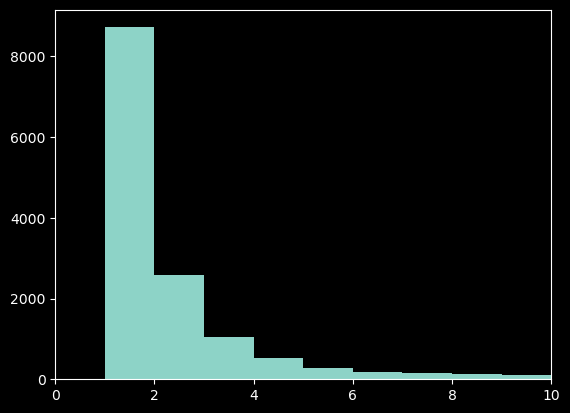

In [33]:
from matplotlib import pyplot as plt
import numpy as np
bins = np.arange(0, 100, 1) # fixed bin size
plt.hist(epoch_distr, bins=bins)
plt.xlim([0, 10])
plt.show()

In [ ]:
import mne 

data = mne.read_edf'/home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaaaao/ses-s0032006/eeg/sub-aaaaaaao_ses-s0032006_task-rest_proc-02tcple_rec-t001_eeg.edf'

In [2]:
import os
from tqdm import tqdm

subjects = [f.path for f in os.scandir("/home/azureuser/mycontainer/TUH-Processed") if f.is_dir()]
print("Subjects length: ", len(subjects))

missing_subjects = []
for subject in tqdm(subjects):
    subject_files = [f.path for f in os.scandir(os.path.join(subject))]
    if len(subject_files) < 3:
        missing_subjects.append(subject)
        
print(len(missing_subjects))

Subjects length:  14987


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14987/14987 [02:36<00:00, 95.80it/s]

929


In [2]:
import mne

In [ ]:
ec = mne.read_epochs("/home/hice1/mchen439/data/HBN-Processed/NDARAR238RZ8/epochs/seqLearning8target.fif")
data = ec.get_data()
print(data.shape)

/tmp/ipykernel_1747398/1518632671.py:1: RuntimeWarning: This filename (/home/hice1/mchen439/data/HBN-Processed/NDARAR238RZ8/epochs/seqLearning8target.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  ec = mne.read_epochs("/home/hice1/mchen439/data/HBN-Processed/NDARAR238RZ8/epochs/seqLearning8target.fif")


Reading /home/hice1/mchen439/data/HBN-Processed/NDARAR238RZ8/epochs/seqLearning8target.fif ...
    Found the data of interest:
        t =       0.00 ...   59996.09 ms
        0 CTF compensation matrices available
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
(4, 19, 15360)


/tmp/ipykernel_1747398/1518632671.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = ec.get_data()


In [3]:
import matplotlib.pyplot as plt
import numpy as np

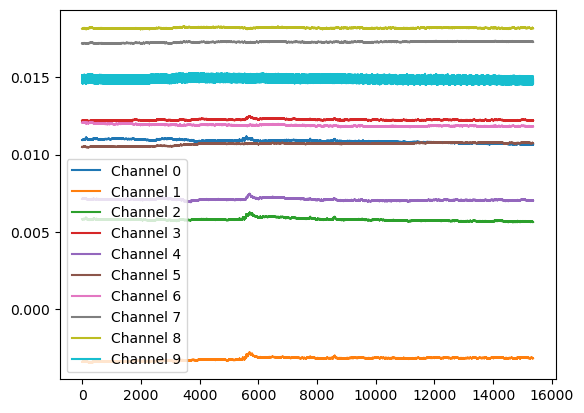

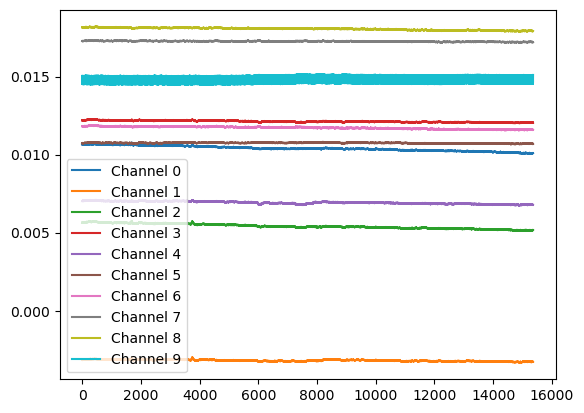

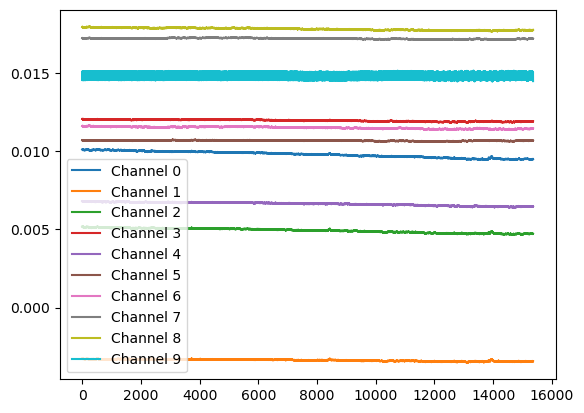

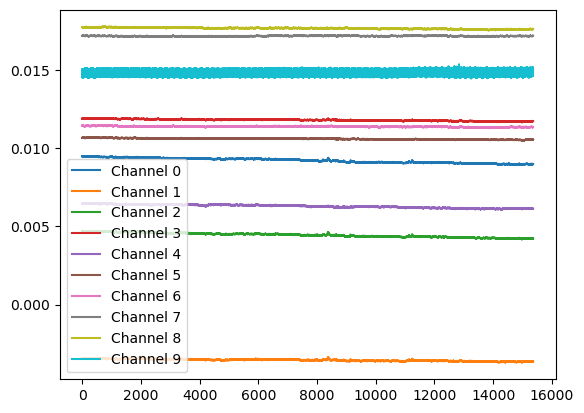

In [36]:
for j in range(data.shape[0]):
	for i in range(10):
		plt.plot(data[j, i, :], label=f"Channel {i}")
	plt.legend()
	plt.show()

In [40]:
from mne_bids import BIDSPath, read_raw_bids

bids_path = BIDSPath(root="/home/hice1/mchen439/data/eegdata/ds005511-download", subject="NDARAR238RZ8", datatype="eeg", suffix="eeg", task="seqLearning8target", extension=".set")
data = read_raw_bids(bids_path, verbose=True)

/tmp/ipykernel_1747398/1783551262.py:4: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  data = read_raw_bids(bids_path, verbose=True)


Reading events from /home/hice1/mchen439/data/eegdata/ds005511-download/sub-NDARAR238RZ8/eeg/sub-NDARAR238RZ8_task-seqLearning8target_events.tsv.


/tmp/ipykernel_1747398/1783551262.py:4: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  data = read_raw_bids(bids_path, verbose=True)


Reading channel info from /home/hice1/mchen439/data/eegdata/ds005511-download/sub-NDARAR238RZ8/eeg/sub-NDARAR238RZ8_task-seqLearning8target_channels.tsv.
Reading electrode coords from /home/hice1/mchen439/data/eegdata/ds005511-download/sub-NDARAR238RZ8/eeg/sub-NDARAR238RZ8_task-seqLearning8target_electrodes.tsv.


In [41]:
data = data.get_data()
print(data.shape)

(129, 149602)


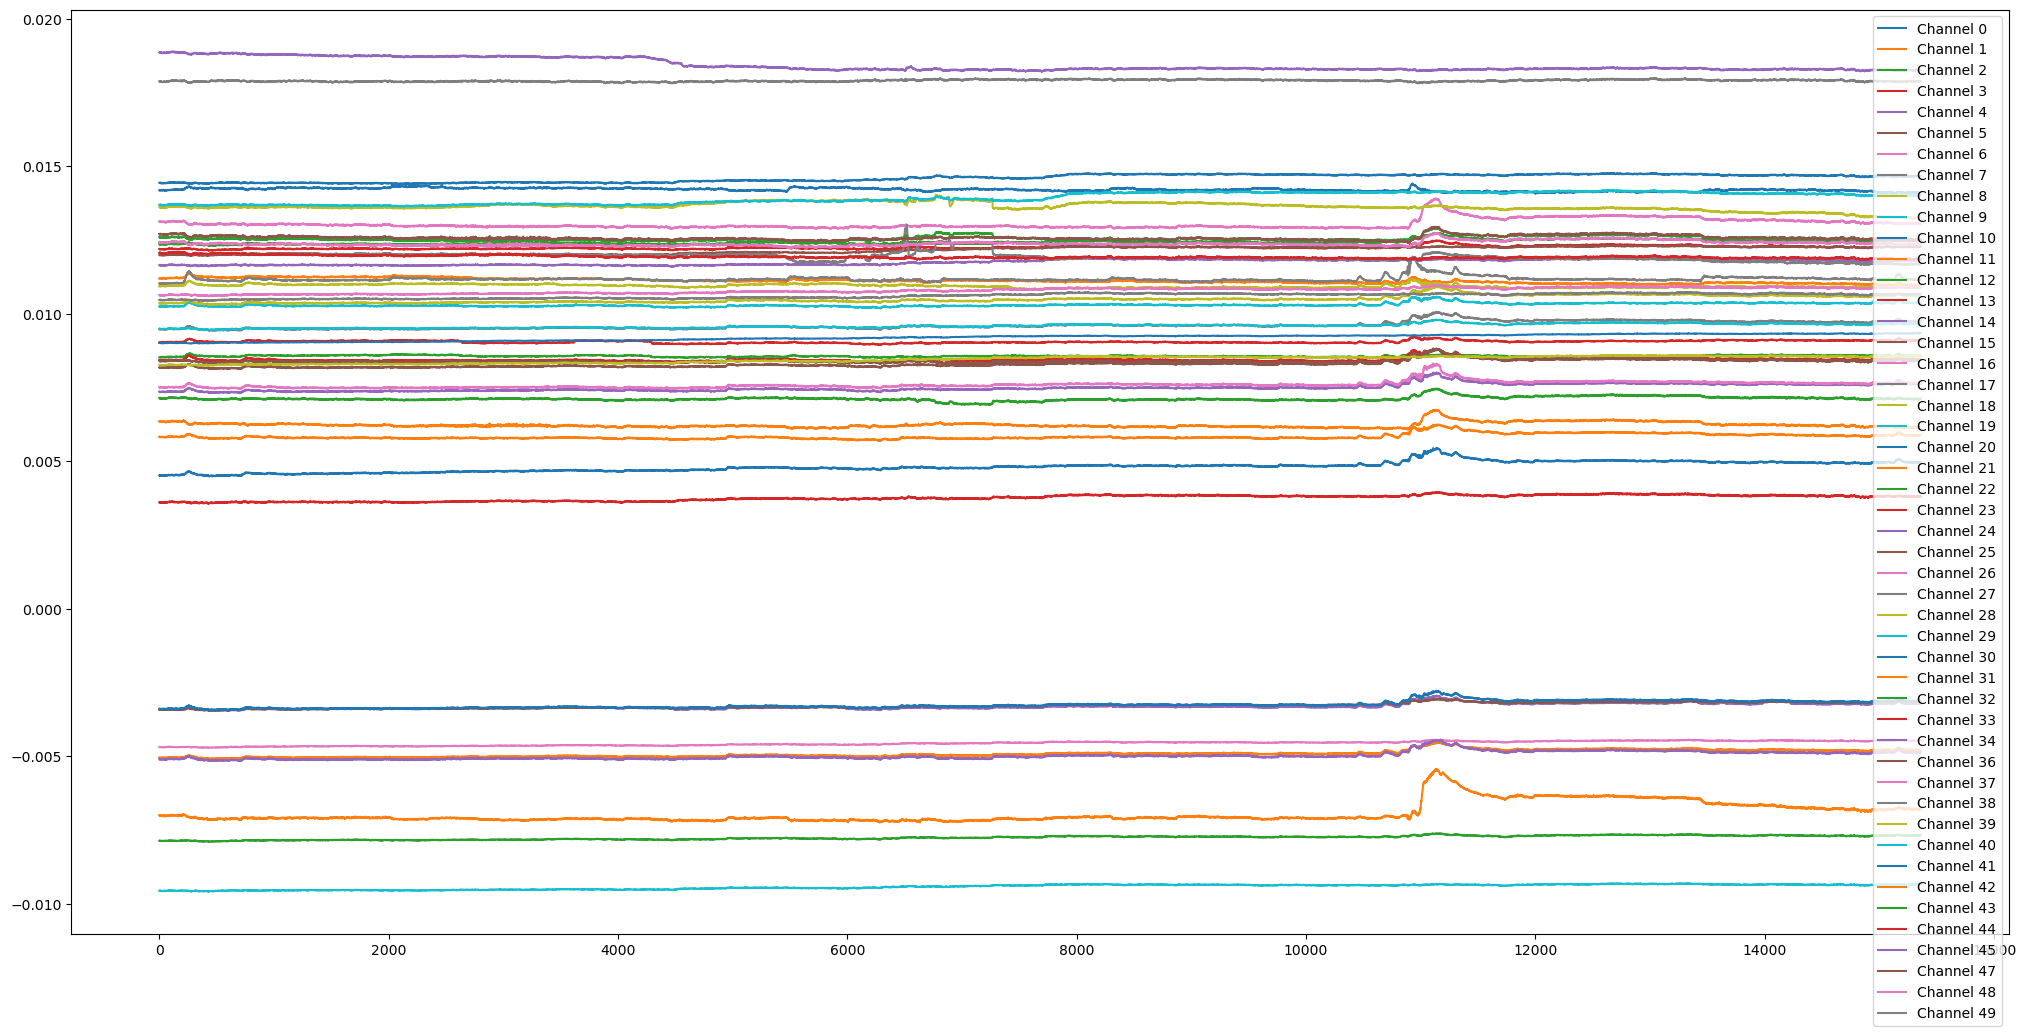

In [42]:
plt.figure(figsize=(25,12))
for i in range(50):
	if i != 35 and i != 46:
		plt.plot(data[i, :15360], label=f"Channel {i}")
plt.legend()
plt.show()

In [4]:
ec = mne.read_epochs("/home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/epochs/s0012015-01tcpar-t000_epo.fif")
data = ec.get_data()
print(data.shape)

Reading /home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/epochs/s0012015-01tcpar-t000_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   59996.09 ms
        0 CTF compensation matrices available
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
(21, 19, 15360)


/tmp/ipykernel_1102196/246190422.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = ec.get_data()


-2.927942487043755e-06 1.6997269860899066e-05
-1.5609126485007414e-06 1.5382068124320278e-05
3.984859134987621e-06 1.7296326803646043e-05
-5.790260673654845e-07 1.4815902154133085e-05
2.672126364441918e-06 1.5726515691965335e-05
1.2274881735959327e-06 1.4713106089952075e-05
-5.675526021837323e-07 1.4940549815086979e-05
-5.8823581075215235e-08 1.4724406705251942e-05
-8.740176584066949e-07 1.526806053348927e-05
-1.971967591570441e-07 1.4856658711003118e-05
-6.664741365478243e-07 1.5631617783496197e-05
-1.1693921631013524e-06 1.6263508387077143e-05
-1.6464391890186567e-06 1.5618692480534647e-05
-5.322294501737546e-07 1.4831947071830872e-05
-1.8906193738422542e-06 1.6105819127190494e-05
-6.02636721506201e-07 1.4854367046030914e-05
-1.5079476472270221e-06 1.5246271813324184e-05
-2.9375617304603733e-06 1.6920699818556478e-05
-1.6659190203113564e-06 1.5630568391211777e-05


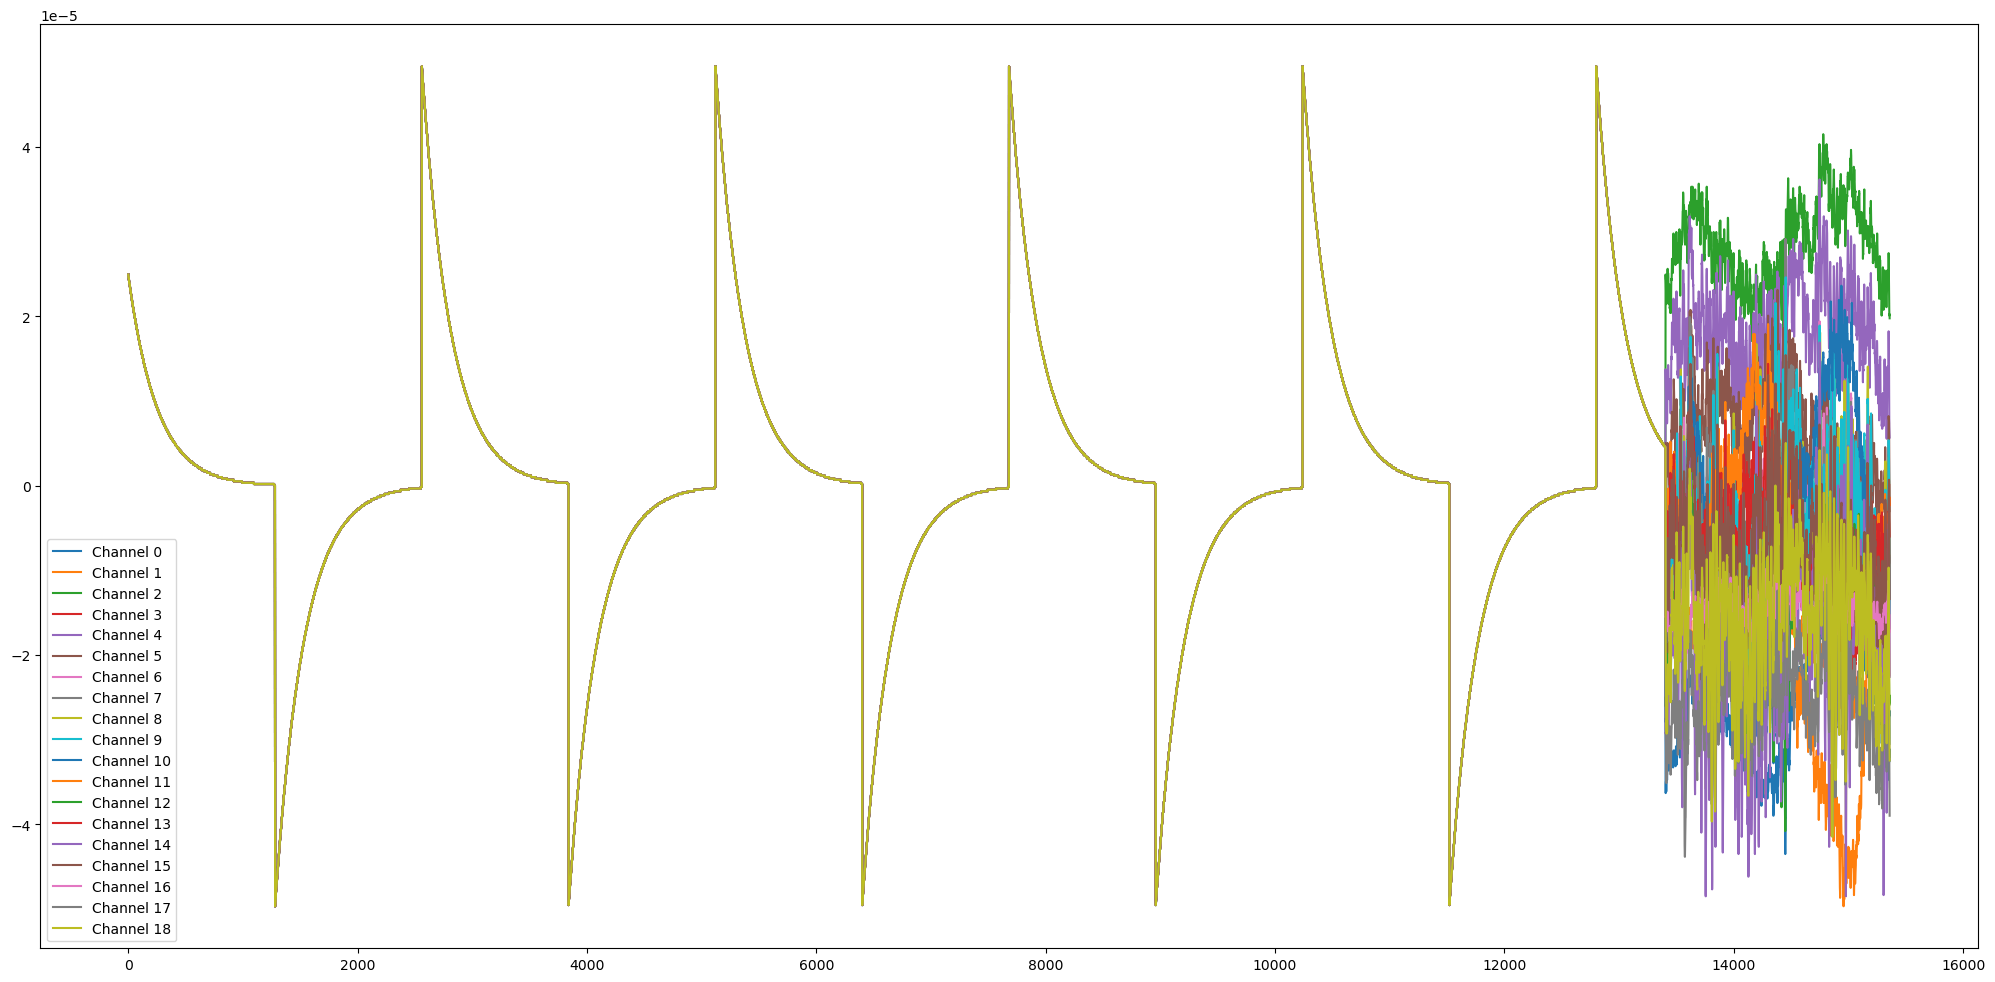

In [5]:
plt.figure(figsize=(25,12))
for i in range(data.shape[1]):
	plt.plot(data[0, i, :], label=f"Channel {i}")
	print(data[0, i, :].mean(), data[0, i, :].std())
plt.legend()
plt.show()

In [22]:
data = np.load("/home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/normalized_epochs/s0012015-01tcpar-t000_epo.fif.npy")
print(data.shape)

(21, 19, 15360)


In [1]:
plt.figure(figsize=(25,12))
for i in range(data.shape[1]):
	plt.plot(data[3, i, :], label=f"Channel {i}")
	print(data[3, i, :].mean(), data[3, i, :].std())	
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [27]:
import torch
from torch_geometric.data import Data

data = torch.load("/home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/graphs/s0012015-01tcpar-t000_epo_epoch_3.pt")
print(data)

/tmp/ipykernel_1747398/3218435416.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("/home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/graphs/s0012015-01t

Data(x=[19, 15360], edge_index=[2, 361], edge_attr=[361, 1], y=[0], pos=[19, 3])


In [28]:
data = data.x

-2.1042125656515222e-05 7.615268913667342e-06
-1.5682888214950398e-05 1.0995762482470888e-05
-2.0659169723553915e-06 1.3990390149932565e-05
-1.2903403472760515e-05 7.802816927697932e-06
-3.3354803410881133e-06 1.8549103422346362e-05
-7.304676000830073e-06 1.636751220851499e-05
-2.4901130571556088e-05 2.1087331215979407e-05
-1.6804442977313634e-05 4.2683632157153255e-05
-1.5093858875651553e-05 2.3495571786716693e-05
-1.2143079699781141e-05 1.9748575637426243e-05
-1.528262342320406e-05 2.5197336463479022e-05
-1.5112364032635976e-05 1.454032637972287e-05
-1.9601998891298256e-05 2.2243388075273458e-05
-1.1700880074413713e-05 1.703881888810139e-05
-1.9558460515044922e-05 2.3173543868940697e-05
-1.591424664319901e-05 1.8479642200995714e-05
-1.8850929926182473e-05 8.82868808806017e-06
-2.3554114331813628e-05 1.619640041461694e-05
-1.836011665787158e-05 2.016448299181496e-05


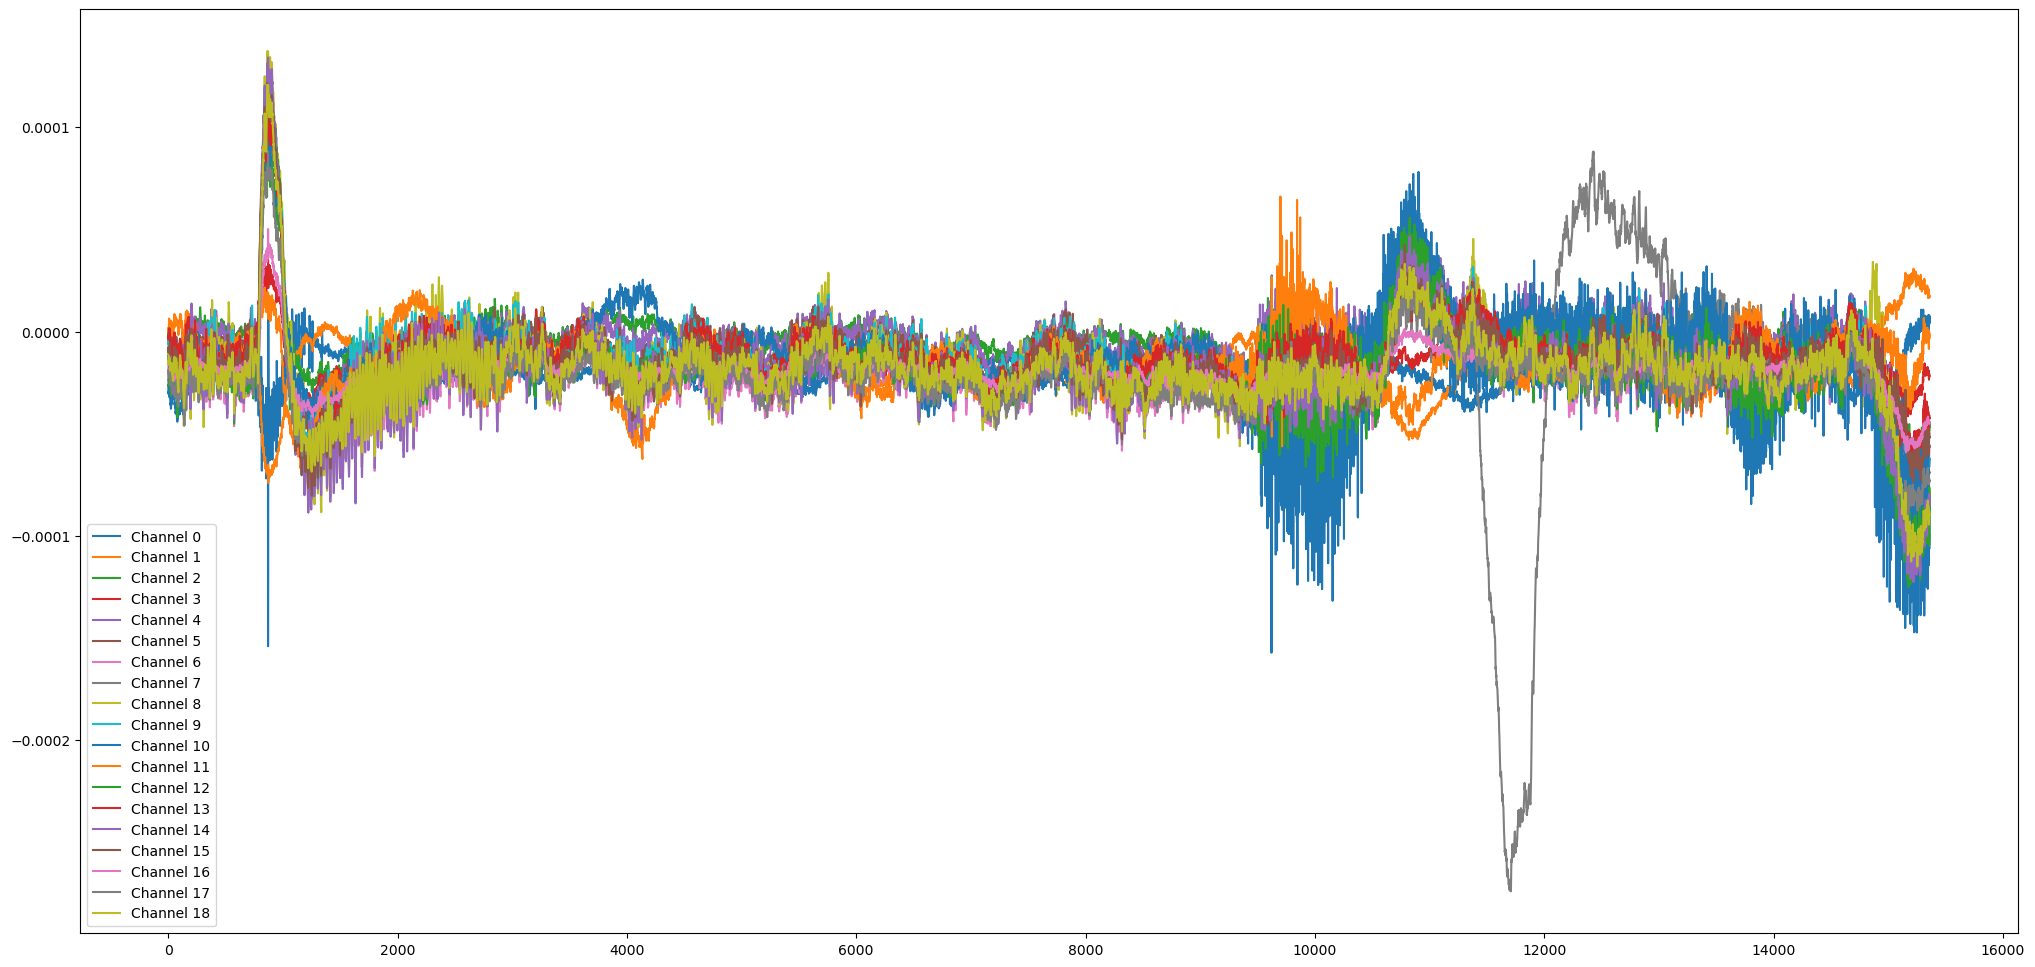

In [30]:
plt.figure(figsize=(25,12))
for i in range(data.shape[0]):
	plt.plot(data[i, :], label=f"Channel {i}")
	print(data[i, :].mean(), data[i, :].std())	
plt.legend()
plt.show()

In [1]:
import torch
import numpy as np
import pywt
import ptwt
import matplotlib.pyplot as plt

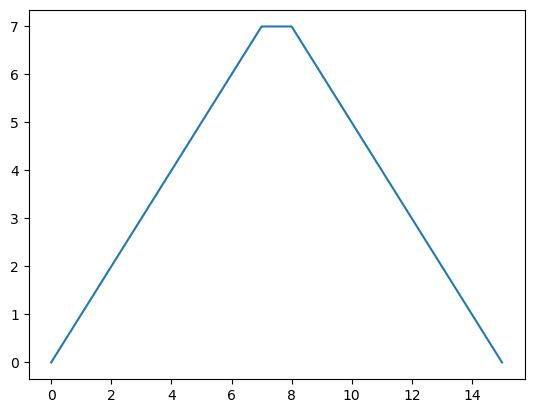

In [4]:
data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 7, 6, 5, 4, 3, 2, 1, 0])
plt.plot(data)
plt.show()
data_torch = torch.from_numpy(data.astype(np.float32))
wavelet = pywt.Wavelet('haar')


In [5]:
# compare the forward fwt coefficients
print(pywt.wavedec(data, wavelet, mode='zero', level=2))
print(ptwt.wavedec(data_torch, wavelet, mode='zero', level=2))

[array([ 3., 11., 11.,  3.]), array([-2., -2.,  2.,  2.]), array([-0.70710678, -0.70710678, -0.70710678, -0.70710678,  0.70710678,
        0.70710678,  0.70710678,  0.70710678])]
[tensor([ 3.0000, 11.0000, 11.0000,  3.0000]), tensor([-2., -2.,  2.,  2.]), tensor([-0.7071, -0.7071, -0.7071, -0.7071,  0.7071,  0.7071,  0.7071,  0.7071])]


tensor([3.1514e-07, 1.0000e+00, 2.0000e+00, 3.0000e+00, 4.0000e+00, 5.0000e+00,
        6.0000e+00, 7.0000e+00, 7.0000e+00, 6.0000e+00, 5.0000e+00, 4.0000e+00,
        3.0000e+00, 2.0000e+00, 1.0000e+00, 1.3632e-07])


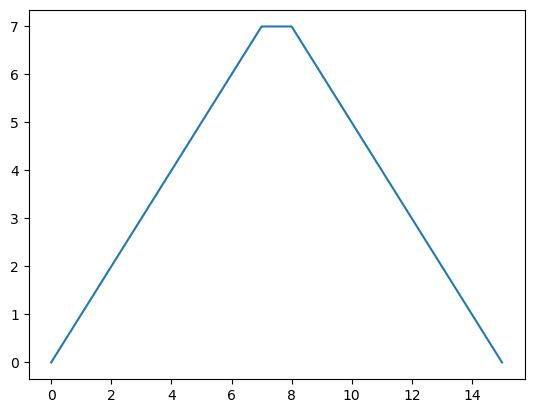

In [7]:
# invert the fwt.
invert = ptwt.waverec(ptwt.wavedec(data_torch, wavelet, mode='zero'), wavelet)
print(invert)
plt.plot(invert)
plt.show()

In [9]:
print(pywt.wavelist(kind='discrete'))
print(ptwt.constants.BoundaryMode)

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']
typing.Literal['constant', 'zero',

In [25]:
x = torch.rand(4, 19, 15360)
print(x.dtype)
db4_transform = ptwt.wavedec(x, 'db5', mode='reflect', level=7, axis=-1)
print(len(db4_transform))


torch.float32


8


In [15]:
from torch_geometric.data import Data
data = torch.load("/home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/graphs/s0012015-01tcpar-t000_epo_epoch_3.pt").x
print(data.shape)

/tmp/ipykernel_3096126/29128094.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("/home/hice1/mchen439/data/TUH-Processed/aaaaaaaa/graphs/s0012015-01tcp

(19, 15360)


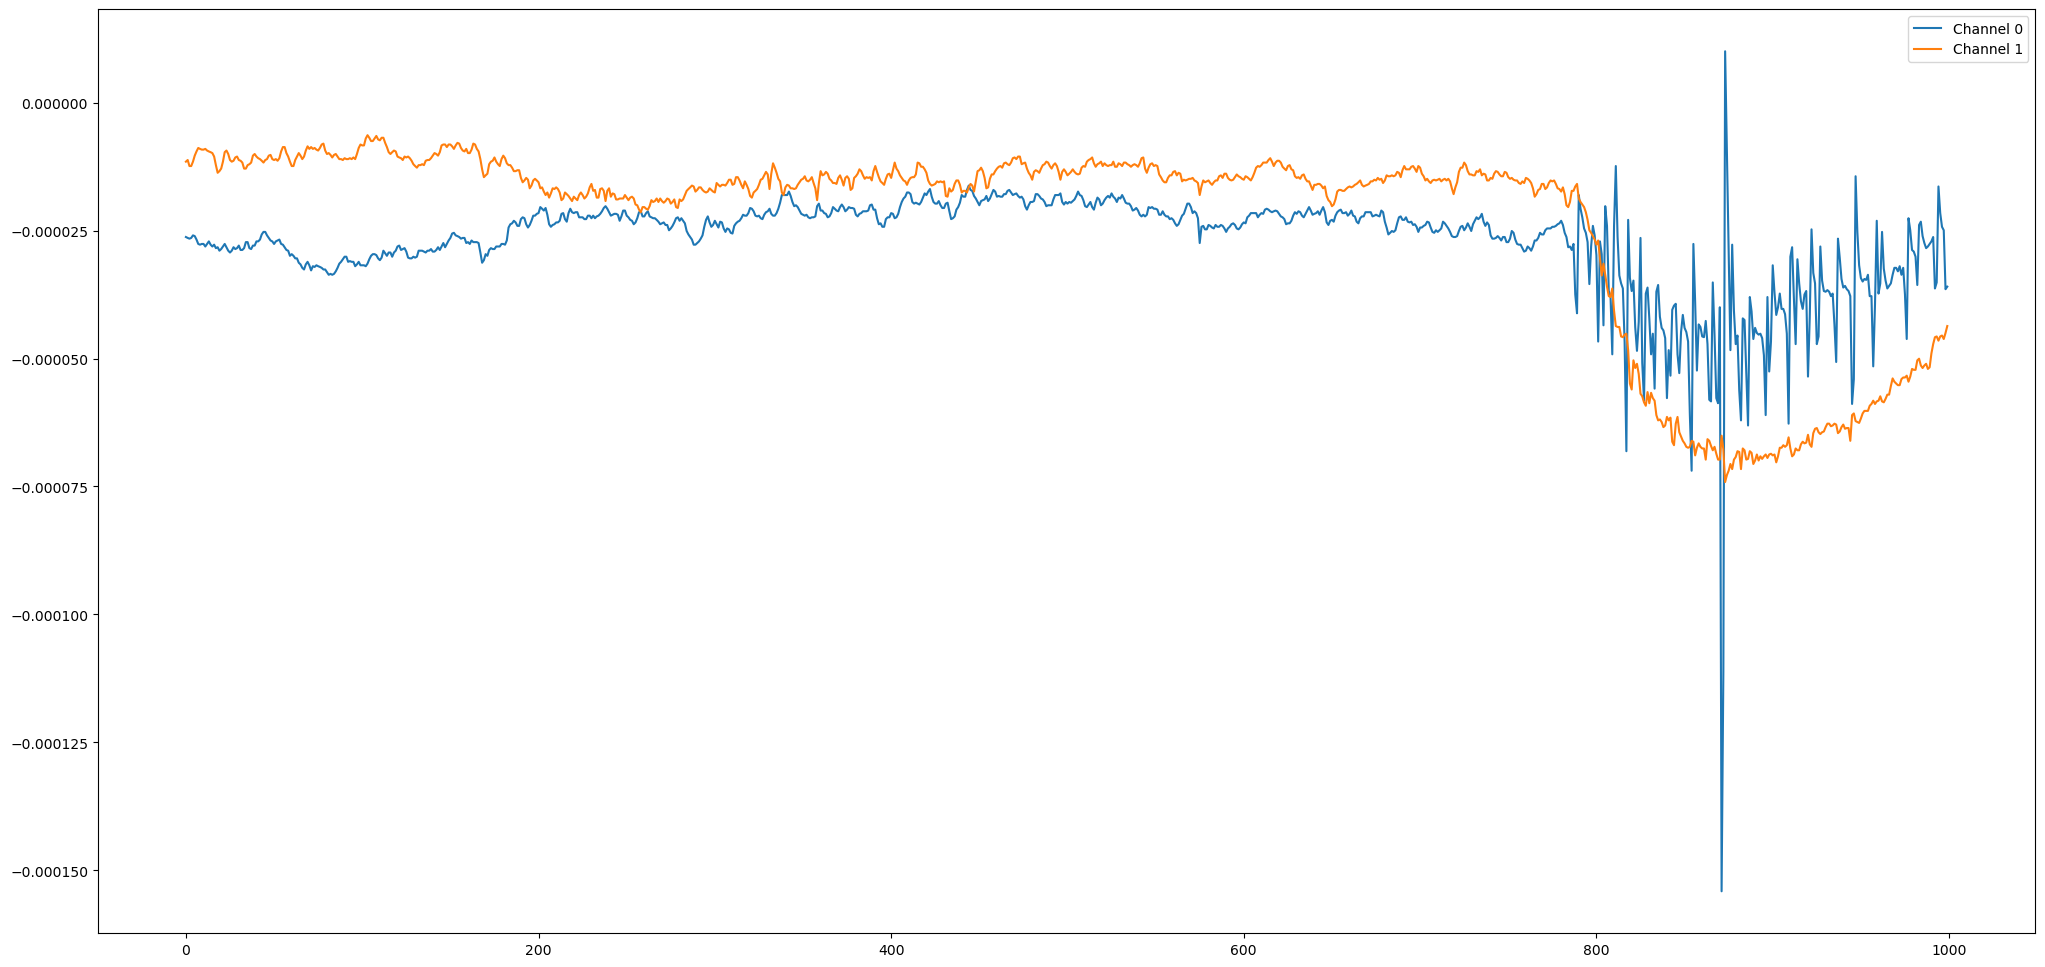

In [31]:
plt.figure(figsize=(25,12))
for i in range(2):
	plt.plot(data[i, :1000], label=f"Channel {i}")
plt.legend()
plt.show()


In [171]:
print(data[0:2, ].shape)
db4_dwpt = ptwt.WaveletPacket(torch.from_numpy(data[0:2, :]), 'db4', mode='reflect', maxlevel=4, axis=-1)
print(len(db4_dwpt))

(2, 15360)
31


In [177]:
for level in db4_dwpt.get_level(3):
	print(level)

print(db4_dwpt['a'].shape)
print(db4_dwpt['aa'].shape)
print(db4_dwpt['aaa'].shape)
print(db4_dwpt['aaaa'].shape)

aaa
aad
add
ada
dda
ddd
dad
daa
torch.Size([2, 7683])
torch.Size([2, 3845])
torch.Size([2, 1926])
torch.Size([2, 966])


In [159]:
db4_dwpt["ad"] = torch.zeros_like(db4_dwpt["da"])
db4_dwpt.reconstruct()
reconstruction = db4_dwpt[""]

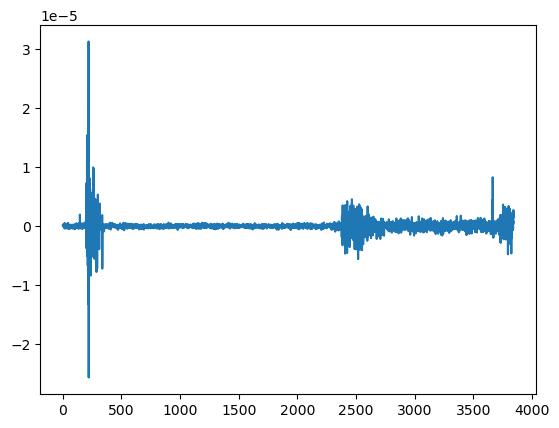

In [164]:
plt.plot(db4_dwpt['da'][0, :])
plt.show()

tensor(2.0102e-22, dtype=torch.float64)
tensor(1.0023e-21, dtype=torch.float64)


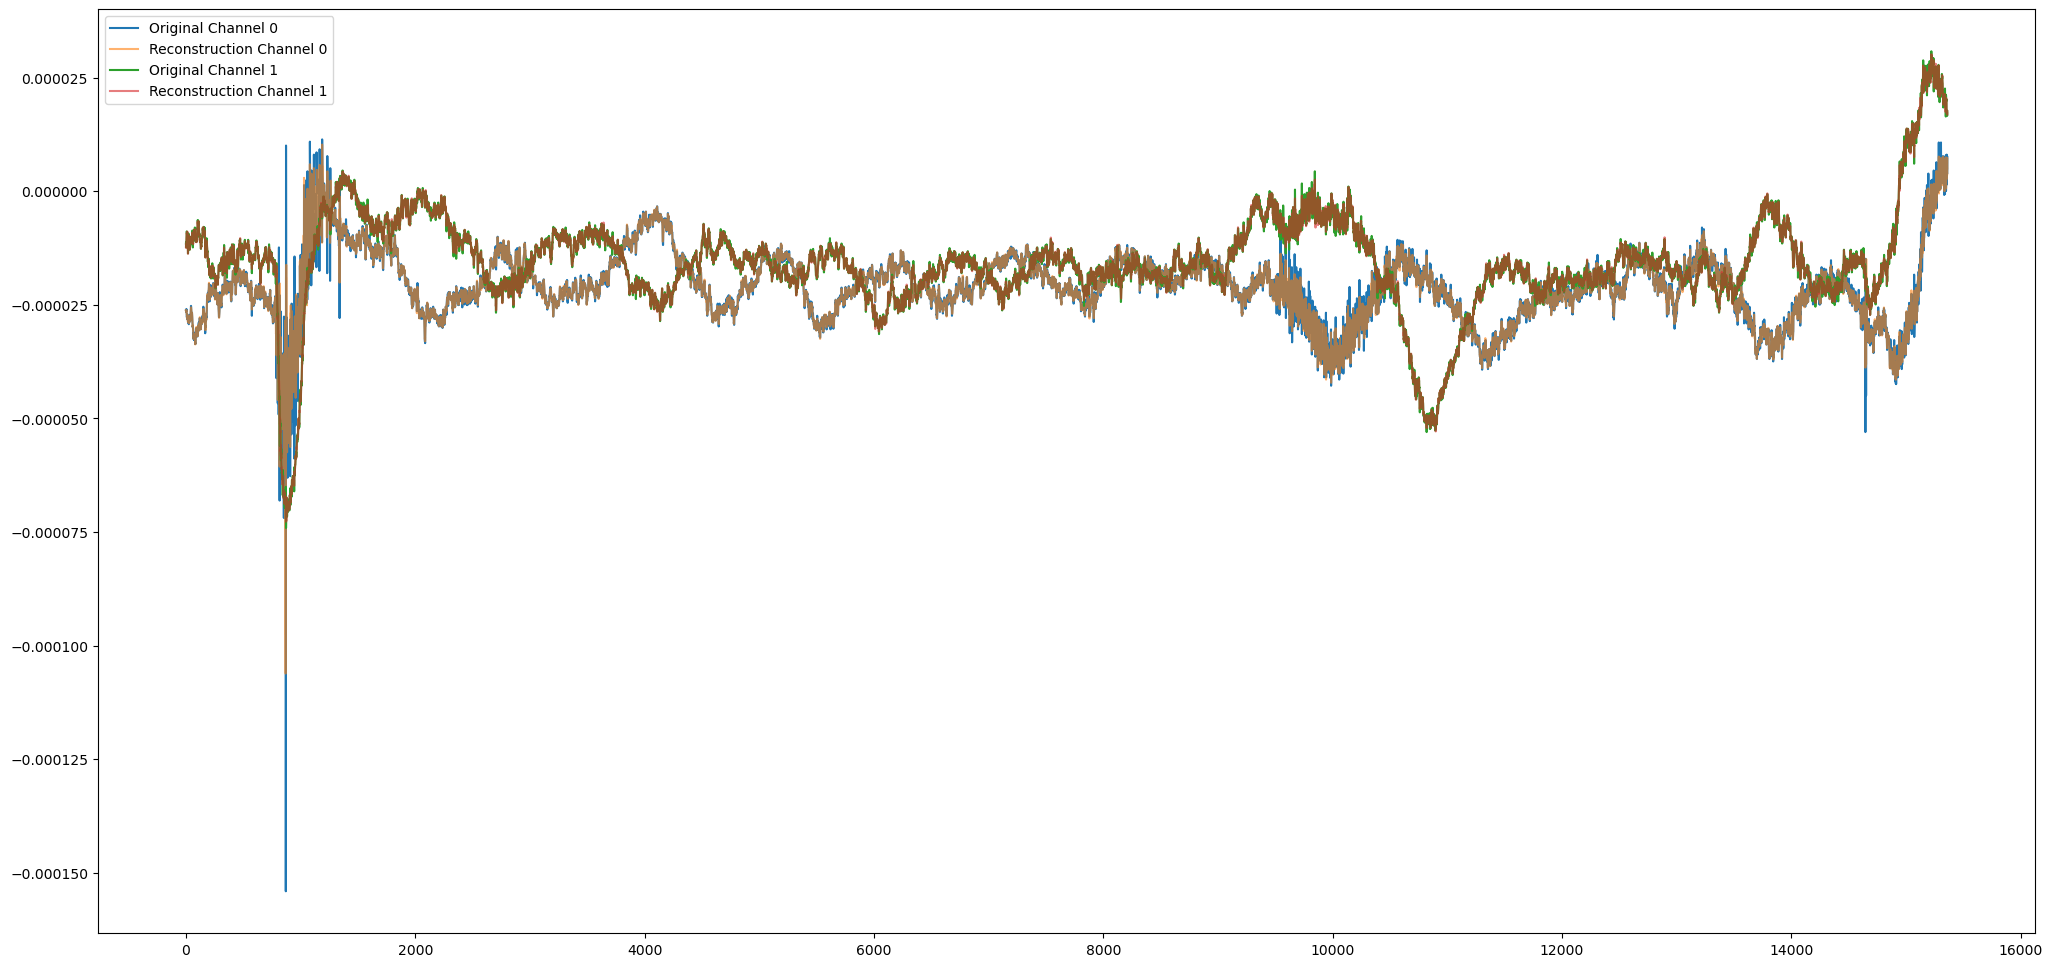

In [160]:
plt.figure(figsize=(25,12))

for i in range(2):
	plt.plot(data[i, :], label=f"Original Channel {i}")
	plt.plot(reconstruction[i, :], label=f"Reconstruction Channel {i}", alpha=0.6)
	print((torch.from_numpy(data[i, :]) - reconstruction[i, :]).mean()**2)
plt.legend()
plt.show()


In [2]:
import torch
import torch.nn as nn
transformer_model = nn.Transformer(nhead=16, num_encoder_layers=12)
src = torch.rand((10, 32, 512))
tgt = torch.rand((20, 32, 512))
out = transformer_model(src, tgt)
print(out.shape)

/home/hice1/mchen439/scratch/miniconda3/envs/Wavelet/lib/python3.9/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


torch.Size([20, 32, 512])


In [4]:
from sys import gettrace
import re
if gettrace() is None:
    try:
        # Find number of cpus available (taken from second answer):
        # https://stackoverflow.com/questions/1006289/how-to-find-out-the-number-of-cpus-using-python
        m = re.search(r'(?m)^Cpus_allowed:\s*(.*)$',
                        open('/proc/self/status').read())
        nw = bin(int(m.group(1).replace(',', ''), 16)).count('1')
        # Cap the number of workers at 6 (actually 4) to avoid pummeling disks too hard
        nw = min(6, nw)
    except FileNotFoundError:
        # Fallback for when proc/self/status does not exist
        nw = 2
    else:
        # 0 workers means not extra processes are spun up
        nw = 2
print(nw)

2


In [4]:
import torch
A = torch.ones(4, 32)
B = torch.ones(4, 32, 32)

result = (A[..., None, :] - A[..., None])

print(result.shape, result.min(), result.max())

torch.Size([4, 32, 32]) tensor(0.) tensor(0.)


In [1]:
import os
from tqdm import tqdm
import math
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

In [2]:
def get_subdirectory_size(path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size

In [3]:
def get_sizes_of_subdirectories(root_dir, subdirectories):
    sizes = {}

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(get_subdirectory_size, os.path.join(root_dir, subdir)): subdir for subdir in subdirectories}
        for future in futures:
            subdir = futures[future]
            sizes[subdir] = future.result()
    return sizes
    '''
    for subdir in subdirectories:
      full_path = os.path.join(root_dir, subdir)
      if os.path.exists(full_path) and os.path.isdir(full_path):
        sizes[subdir] = get_subdirectory_size(full_path)
      else:
        sizes[subdir] = "Subdirectory not found"
    return sizes'
    '''

In [4]:
subjects = [f.path.split("/")[-1] for f in os.scandir("/home/azureuser/mycontainer/TUH-Processed") if f.is_dir()]
print("Subjects: ", len(subjects))

Subjects:  14987


In [5]:
sub_directory_sizes = {
	"epochs_v128Hz": 0,
	"epochs_v256Hz": 0,
	"graphs_v128Hz": 0,
	"graphs_v256Hz": 0,
	"wavelet_decompositions_v128Hz": 0,
	"wavelet_decompositions_v256Hz": 0,
}

with ProcessPoolExecutor(max_workers=24) as executor:
	futures = {executor.submit(get_sizes_of_subdirectories, os.path.join("/home/azureuser/mycontainer/TUH-Processed", subject), list(sub_directory_sizes.keys())): subject for subject in subjects}
	for future in tqdm(futures):
		sizes = future.result()
		for subdir in sizes.keys():
			sub_directory_sizes[subdir] += sizes[subdir]
'''
for subject in tqdm(subjects):
	subdirectories = [f.path.split("/")[-1] for f in os.scandir(f"/home/azureuser/mycontainer/TUH-Processed/{subject}")]
	sizes = get_sizes_of_subdirectories(f"/home/azureuser/mycontainer/TUH-Processed/{subject}", list(sub_directory_sizes.keys()))
	for subdir in sub_directory_sizes.keys():
		if subdir in sizes:
			sub_directory_sizes[subdir] += sizes[subdir]'
'''

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14987/14987 [05:07<00:00, 48.68it/s]


'\nfor subject in tqdm(subjects):\n\tsubdirectories = [f.path.split("/")[-1] for f in os.scandir(f"/home/azureuser/mycontainer/TUH-Processed/{subject}")]\n\tsizes = get_sizes_of_subdirectories(f"/home/azureuser/mycontainer/TUH-Processed/{subject}", list(sub_directory_sizes.keys()))\n\tfor subdir in sub_directory_sizes.keys():\n\t\tif subdir in sizes:\n\t\t\tsub_directory_sizes[subdir] += sizes[subdir]\'\n'

In [6]:
def convert_size(size_bytes):
   if size_bytes == 0:
       return "0B"
   size_name = ("B", "KB", "MB", "GB", "TB", "PB", "EB", "ZB", "YB")
   i = int(math.floor(math.log(size_bytes, 1024)))
   p = math.pow(1024, i)
   s = round(size_bytes / p, 2)
   return "%s %s" % (s, size_name[i])

In [7]:
for subdir in sub_directory_sizes.keys():
	print(f"{subdir}: {convert_size(sub_directory_sizes[subdir])}")

epochs_v128Hz: 227.58 GB
epochs_v256Hz: 318.47 GB
graphs_v128Hz: 427.8 GB
graphs_v256Hz: 855.01 GB
wavelet_decompositions_v128Hz: 285.83 GB
wavelet_decompositions_v256Hz: 285.94 GB


In [66]:
import mne
from mne_bids import BIDSPath, read_raw_bids
path = BIDSPath(root="~/mycontainer/HBN/ds005515", subject="NDARNF362NU0", task="contrastChangeDetection", run=1, datatype="eeg", suffix="eeg", extension=".set")
raw = read_raw_bids(path, verbose=True)
print(raw.info)
print(raw.times[0], raw.times[-1])


Reading events from /home/azureuser/mycontainer/HBN/ds005515/sub-NDARNF362NU0/eeg/sub-NDARNF362NU0_task-contrastChangeDetection_run-1_events.tsv.


/anaconda/envs/EEG/lib/python3.10/site-packages/pymatreader/utils.py:283: UserWarning: pymatreader cannot import Matlab string variables. Please convert these variables to char arrays in Matlab.
  warn(
/tmp/ipykernel_11524/341044901.py:4: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = read_raw_bids(path, verbose=True)


Reading channel info from /home/azureuser/mycontainer/HBN/ds005515/sub-NDARNF362NU0/eeg/sub-NDARNF362NU0_task-contrastChangeDetection_run-1_channels.tsv.
<Info | 10 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 129 misc
 custom_ref_applied: False
 dig: 132 items (3 Cardinal, 129 EEG)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 129
 projs: []
 sfreq: 500.0 Hz
 subject_info: 2 items (dict)
>
0.0 276.082


/tmp/ipykernel_11524/341044901.py:4: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  raw = read_raw_bids(path, verbose=True)
/tmp/ipykernel_11524/341044901.py:4: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  raw = read_raw_bids(path, verbose=True)
/tmp/ipykernel_11524/341044901.py:4: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  raw = read_raw_bids(path, verbose=True)
/tmp/ipykernel_11524/341044901.py:4: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E4" will be set to "misc".
  raw = read_raw_bids(path, verbose=True)
/tmp/ipykernel_11524/341044901.py:4: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E5" will be set to "misc".
  raw = read_raw_bids(path, verbose=True)
/tmp/ipykernel_11524/341044901.py:4: Run

In [68]:
# Get types for a list of channels
print(raw.info['ch_names'])
channel_types = [mne.channel_type(raw.info, i) for i in range(129)]
print(f"Types of first 10 channels: {channel_types}")

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'Cz']
Types of first 10 channels: ['misc', 'misc', 'misc', 'misc', 'misc', 'misc', 

In [69]:
ELECTRODES = [f'E{i}' for i in range(1, 129)]
HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}
TO_DROP = [electrode for electrode in ELECTRODES if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_ELECTRODE_MAP_REVERSED = dict((v,k) for k,v in HBN_ELECTRODE_MAP.items())


In [70]:
raw.drop_channels(TO_DROP)
raw.rename_channels(HBN_ELECTRODE_MAP_REVERSED)

<RawEEGLAB | sub-NDARNF362NU0_task-contrastChangeDetection_run-1_eeg.set, 19 x 138042 (276.1 s), ~20.1 MB, data loaded>

In [71]:
# Get types for a list of channels
print(raw.info['ch_names'])
channel_types = [mne.channel_type(raw.info, i) for i in range(19)]
print(f"Types of first 10 channels: {channel_types}")

['Fp2', 'Fz', 'Fp1', 'F3', 'F7', 'C3', 'T3', 'P3', 'T5', 'Pz', 'O1', 'O2', 'P4', 'T6', 'C4', 'T4', 'F8', 'F4', 'Cz']
Types of first 10 channels: ['misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc', 'misc']


In [73]:
raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names})

/tmp/ipykernel_11524/1718712583.py:1: RuntimeWarning: The unit for channel(s) C3, C4, Cz, F3, F4, F7, F8, Fp1, Fp2, Fz, O1, O2, P3, P4, Pz, T3, T4, T5, T6 has changed from NA to V.
  raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names})


<RawEEGLAB | sub-NDARNF362NU0_task-contrastChangeDetection_run-1_eeg.set, 19 x 138042 (276.1 s), ~20.1 MB, data loaded>

In [74]:
from Preprocessing.preprocessingPipeline import simplePipeline
epochs = simplePipeline(raw, sample_rate=128, low_pass=75)

Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 4 events and 30000 original time points ...
0 bad epochs dropped


In [1]:
import torch
from torch_geometric.data import Data

In [2]:
data = torch.load('/home/azureuser/mycontainer/TUH-256Hz/aaaaaaaa/graphs_v256Hz/s0012015-01tcpar-t000_epo_graph.pt')

/tmp/ipykernel_69730/2829281049.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('/home/azureuser/mycontainer/TUH-256Hz/aaaaaaaa/graphs_v256Hz/s0012015-

In [3]:
print(data)

Data(edge_index=[2, 361], edge_attr=[361, 1], pos=[19, 3])


In [4]:
data = torch.load('/home/azureuser/mycontainer/TUH-256Hz/aaaaaaaa/wavelet_decompositions_v256Hz/s0012015-01tcpar-t000_epo_high_freq_band_epoch_28.pt')

/tmp/ipykernel_70002/2091446543.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('/home/azureuser/mycontainer/TUH-256Hz/aaaaaaaa/wavelet_decompositions_

In [5]:
print(data.shape)

torch.Size([19, 3845])


In [2]:
data = torch.load('/home/azureuser/mycontainer/TUH-Processed/aaaaahko/graphs_v256Hz/s0012008-02tcple-t001_epo_graph.pt')

/tmp/ipykernel_70885/2053088289.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('/home/azureuser/mycontainer/TUH-Processed/aaaaahko/graphs_v256Hz/s0012

In [3]:
print(data)

Data(x=[17, 19, 15360], edge_index=[2, 361], edge_attr=[361, 1], pos=[19, 3])


In [8]:
import os
import mne
from tqdm import tqdm

In [ ]:
minutes = 0
for root, dirs, files in tqdm(os.walk("/home/azureuser/mycontainer/TUAB/v3.0.1/edf/eval")):
	for file in files:
		if file.endswith(".edf"):
			raw = mne.io.read_raw_edf(os.path.join(root, file), verbose=False)
			minutes += raw.get_data().shape[1] / raw.info['sfreq'] / 60
print(minutes)


5it [01:07, 13.50s/it]

6176.299999999998


In [13]:
minutes = 0
for root, dirs, files in tqdm(os.walk("/home/azureuser/mycontainer/TUAB_processed/epoched_data/eval")):
	for file in files:
		if file.endswith(".fif"):
			epochs = mne.read_epochs(os.path.join(root, file), verbose=False)
			minutes += epochs.get_data(copy=True).shape[0]

print(minutes)


3it [00:35, 11.80s/it]

6067


In [14]:
minutes = 0
for root, dirs, files in os.walk("/home/azureuser/mycontainer/TUAB/v3.0.1/edf/train"):
	for file in tqdm(files):
		if file.endswith(".edf"):
			raw = mne.io.read_raw_edf(os.path.join(root, file), verbose=False)
			minutes += raw.get_data().shape[1] / raw.info['sfreq'] / 60
print(minutes)


0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

62283.83333333344


In [15]:
minutes = 0
for root, dirs, files in os.walk("/home/azureuser/mycontainer/TUAB_processed/epoched_data/train"):
	for file in tqdm(files):
		if file.endswith(".fif"):
			epochs = mne.read_epochs(os.path.join(root, file), verbose=False)
			minutes += epochs.get_data(copy=True).shape[0]
print(minutes)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1371/1371 [03:33<00:00,  6.42it/s]

61223


In [7]:
import pandas as pd

In [8]:
profileTiny = pd.read_csv("ProfileData/TinyContextualizer.csv")
print(profileTiny.columns)

Index(['Unnamed: 0', 'key', 'count', 'node_id', 'is_async', 'is_remote',
       'use_device', 'cpu_time_total', 'device_time_total',
       'self_cpu_time_total', 'self_device_time_total', 'input_shapes',
       'stack', 'scope', 'cpu_memory_usage', 'device_memory_usage',
       'self_cpu_memory_usage', 'self_device_memory_usage', 'cpu_children',
       'cpu_parent', 'device_type', 'is_legacy', 'flops',
       'is_user_annotation'],
      dtype='object')


In [6]:
profileTiny = profileTiny[['key', 'count', 'cpu_time_total', 'device_time_total', 'cpu_memory_usage', 'device_memory_usage']]

In [39]:
import torch
import numpy as np
from types import SimpleNamespace

In [83]:
x = torch.from_numpy(np.array([[2, 1, 0], [1, 3, 1], [0, 1, 2]], np.float32)).float()
u, s, v = torch.svd(x)
ss, uu = torch.linalg.eigh(x)
print(s, ss)
print(u, uu)
print(u @ torch.diag_embed(s) @ v)
print(uu @ torch.diag_embed(ss) @ uu.T)
input_self = SimpleNamespace()
input_self.saved_tensors = uu, ss, uu
'''
U = torch.from_numpy(np.array([[1, -1, 1], 
                                [2, 0, -1],
                                [1, 1, 1]], np.float32)).float()
S = torch.tensor([16, 4, 1]).float()
V = U.T
print(U.shape, S.shape, V.shape)
print(torch.matmul(torch.matmul(U, torch.diag(S)), V))
'''

tensor([4.0000, 2.0000, 1.0000]) tensor([1.0000, 2.0000, 4.0000])
tensor([[-4.0825e-01,  7.0711e-01,  5.7735e-01],
        [-8.1650e-01, -1.2673e-07, -5.7735e-01],
        [-4.0825e-01, -7.0711e-01,  5.7735e-01]]) tensor([[ 5.7735e-01, -7.0711e-01,  4.0825e-01],
        [-5.7735e-01, -9.4078e-08,  8.1650e-01],
        [ 5.7735e-01,  7.0711e-01,  4.0825e-01]])
tensor([[-0.7237, -1.5629, -1.4260],
        [ 1.5690, -1.9012, -2.2190],
        [ 1.5857, -1.5629,  0.2070]])
tensor([[ 2.0000e+00,  1.0000e+00, -5.5043e-07],
        [ 1.0000e+00,  3.0000e+00,  1.0000e+00],
        [-5.5043e-07,  1.0000e+00,  2.0000e+00]])


'\nU = torch.from_numpy(np.array([[1, -1, 1], \n                                [2, 0, -1],\n                                [1, 1, 1]], np.float32)).float()\nS = torch.tensor([16, 4, 1]).float()\nV = U.T\nprint(U.shape, S.shape, V.shape)\nprint(torch.matmul(torch.matmul(U, torch.diag(S)), V))\n'

In [78]:
def safe_inverse(x, epsilon=1E-12):
	return x/(x**2 + epsilon)

def backward(self, dU, dS, dV):
    U, S, V = self.saved_tensors
    print(S.shape)
    Vt = V.t()
    Ut = U.t()
    M = U.size(0)
    N = V.size(0)
    NS = len(S)

    F = (S - S[:, None])
    F = safe_inverse(F)
    F.diagonal().fill_(0)

    G = (S + S[:, None])
    G.diagonal().fill_(np.inf)
    G = 1/G 

    UdU = Ut @ dU
    VdV = Vt @ dV

    print(UdU)

    Su = (F+G)*(UdU-UdU.t())/2
    Sv = (F-G)*(VdV-VdV.t())/2

    print("su", Su)
    print("sv", Sv)

    dA = U @ (Su + Sv + torch.diag(dS)) @ Vt

    if (M>NS):
        print("Here")
        dA = dA + (torch.eye(M, dtype=dU.dtype, device=dU.device) - U@Ut) @ (dU/S) @ Vt 
    if (N>NS):
        print("Here")
        dA = dA + (U/S) @ dV.t() @ (torch.eye(N, dtype=dU.dtype, device=dU.device) - V@Vt)
    return dA

In [79]:
dA = backward(input_self, dS=torch.ones(3), dU=torch.ones(3, 3), dV=torch.ones(3,3))
print(dA)

torch.Size([3])
tensor([[ 5.7735e-01,  5.7735e-01,  5.7735e-01],
        [-1.1921e-07, -1.1921e-07, -1.1921e-07],
        [ 1.6330e+00,  1.6330e+00,  1.6330e+00]])
su tensor([[ 0.0000,  0.3849, -0.2815],
        [ 0.1925,  0.0000, -0.5443],
        [-0.0704, -0.2722,  0.0000]])
sv tensor([[ 0.0000,  0.1925, -0.0704],
        [ 0.3849,  0.0000, -0.2722],
        [-0.2815, -0.5443,  0.0000]])
tensor([[ 0.8341,  0.6242, -0.1659],
        [ 0.6242,  1.3318, -0.7900],
        [-0.1659, -0.7900,  0.8341]])


In [19]:
import torch

B, N, N = 2, 2, 2
torch.manual_seed(2)
x = torch.rand(2, N, dtype=torch.float64, requires_grad=True)

In [20]:
print(x, x.shape, x[:, None].shape)
print(x[..., None, :] - x[..., None], (x - x[:, None]).shape)

tensor([[0.9176, 0.0969],
        [0.7088, 0.5403]], dtype=torch.float64, requires_grad=True) torch.Size([2, 2]) torch.Size([2, 1, 2])
tensor([[[ 0.0000, -0.8206],
         [ 0.8206,  0.0000]],

        [[ 0.0000, -0.1685],
         [ 0.1685,  0.0000]]], dtype=torch.float64, grad_fn=<SubBackward0>) torch.Size([2, 2, 2])


In [21]:
torch.manual_seed(2)
x = torch.rand(N, dtype=torch.float64, requires_grad=True)
print(x, x.shape, x[:, None].shape)
print(x - x[: None], (x - x[:, None]).shape)

tensor([0.9176, 0.0969], dtype=torch.float64, requires_grad=True) torch.Size([2]) torch.Size([2, 1])
tensor([0., 0.], dtype=torch.float64, grad_fn=<SubBackward0>) torch.Size([2, 2])


In [1]:
import torch
import Model.MENDR.safeSVD as safe
N = 2
torch.manual_seed(2)
x = torch.rand(1, N, N, dtype=torch.float64)
print(x)

tensor([[[0.9176, 0.0969],
         [0.7088, 0.5403]]], dtype=torch.float64)


In [2]:
u, s, v = safe.SVD.apply(x)
uu, ss, vv = safe.SVD2.apply(x[0])
print(u, s, v)
print(uu, ss, vv)

tensor([[[-0.7213, -0.6926],
         [-0.6926,  0.7213]]], dtype=torch.float64) tensor([[1.2353, 0.3457]], dtype=torch.float64) tensor([[[-0.9331, -0.3595],
         [-0.3595,  0.9331]]], dtype=torch.float64)
tensor([[-0.7213, -0.6926],
        [-0.6926,  0.7213]], dtype=torch.float64) tensor([1.2353, 0.3457], dtype=torch.float64) tensor([[-0.9331, -0.3595],
        [-0.3595,  0.9331]], dtype=torch.float64)


In [3]:
from types import SimpleNamespace
print(s, ss)
ctx1 = SimpleNamespace(saved_tensors=(u, s, v))
dA1 = safe.SVD.backward(ctx1, torch.ones(1, 2, 2).double(), torch.ones(1, 2).double(), torch.ones(1, 2, 2).double())

ctx2 = SimpleNamespace(saved_tensors=(uu, ss, vv))
dA2 = safe.SVD2.backward(ctx2, torch.ones(2, 2).double(), torch.ones(2).double(), torch.ones(2, 2).double())

tensor([[1.2353, 0.3457]], dtype=torch.float64) tensor([1.2353, 0.3457], dtype=torch.float64)
tensor([[[ 0.0000, -0.8896],
         [ 0.8896,  0.0000]]], dtype=torch.float64)
tensor([[[ 0.0000, -1.1241],
         [ 1.1241,  0.0000]]], dtype=torch.float64)
tensor([[ 0.0000, -0.8896],
        [ 0.8896,  0.0000]], dtype=torch.float64)
tensor([[ 0.0000, -1.1241],
        [ 1.1241,  0.0000]], dtype=torch.float64)


In [30]:
print(dA1.shape, dA2.shape)

torch.Size([1, 2, 2]) torch.Size([2, 2])


In [31]:
print(dA1)

tensor([[[ 2.0374,  0.0427],
         [-0.7746,  0.4746]]], dtype=torch.float64)


In [32]:
print(dA2)

tensor([[ 2.5544, -1.2992],
        [-0.2782, -0.8139]], dtype=torch.float64)


In [1]:
import torch
import Model.MENDR.safeSVD as safe
N = 2
torch.manual_seed(2)
x = torch.rand(1, N, N, dtype=torch.float64)
x = x + x.permute(0, 2, 1)

In [2]:
s, v = safe.Eigh.apply(x)
ss, vv = safe.EigenSolver.apply(x[0])
print(s, v)
print(ss, vv)

tensor([[0.5682, 2.3475]], dtype=torch.float64) tensor([[[ 0.5366, -0.8438],
         [-0.8438, -0.5366]]], dtype=torch.float64)
tensor([0.5682, 2.3475], dtype=torch.float64) tensor([[ 0.5366, -0.8438],
        [-0.8438, -0.5366]], dtype=torch.float64)


In [55]:
import torch
from scipy.signal import resample
import pickle
import numpy as np
from tqdm import tqdm

In [56]:
class TUEVLoader(torch.utils.data.Dataset):
    def __init__(self, root, files, sampling_rate=200):
        self.root = root
        self.files = files
        self.default_rate = 256
        self.sampling_rate = sampling_rate

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = pickle.load(open(os.path.join(self.root, self.files[index]), "rb"))
        #X = sample["signal"]
        # 256 * 5 -> 1000, from 256Hz to ?
        '''
        if self.sampling_rate != self.default_rate:
            X = resample(X, 5 * self.sampling_rate, axis=-1)
        X = X / (
            np.quantile(np.abs(X), q=0.95, method="linear", axis=-1, keepdims=True)
            + 1e-8
        )
        '''
        Y = int(sample["label"][0] - 1)
        #X = torch.FloatTensor(X)
        return None, Y

In [57]:
root = "/home/azureuser/mycontainer/TUEV/v2.0.1/edf"

In [58]:
train_files = os.listdir(os.path.join(root, "processed_train"))
eval_files = os.listdir(os.path.join(root, "processed_eval"))
print(len(train_files), len(eval_files))

83932 29421


In [59]:
train_loader = TUEVLoader(os.path.join(root, "processed_train"), train_files, sampling_rate=200)
eval_loader = TUEVLoader(os.path.join(root, "processed_eval"), eval_files, sampling_rate=200)
print(len(train_loader), len(eval_loader))

83932 29421


In [60]:
label_count = {
	0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
}

for i in tqdm(range(len(train_loader))):
	_, Y = train_loader[i]
	label = Y
	assert label >= 0 and label <= 5, f"Label {label} is not in range [0, 5]"
	label_count[label] += 1

print(label_count)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 83932/83932 [19:58<00:00, 70.01it/s]

{0: 645, 1: 11254, 2: 6184, 3: 1070, 4: 11053, 5: 53726}


In [61]:
label_count = {
	0: 0,
	1: 0,
	2: 0,
	3: 0,
	4: 0,
	5: 0,
}

for i in range(len(eval_loader)):
	_, Y = eval_loader[i]
	label = Y
	assert label >= 0 and label <= 5, f"Label {label} is not in range [0, 5]"
	label_count[label] += 1
print(label_count)
	

{0: 567, 1: 4677, 2: 1998, 3: 329, 4: 2204, 5: 19646}


In [ ]:
import mne

In [2]:
import numpy as np

In [2]:
balanced_acc = np.asarray([0.8231, 0.8217, 0.8206, 0.8223, 0.8258])
auc_pr = np.asarray([0.9098, 0.9093, 0.9082, 0.9098, 0.9155])
auroc = np.asarray([0.9055, 0.9067, 0.9059, 0.9071, 0.9141])

print(balanced_acc.mean(), balanced_acc.std())
print(auc_pr.mean(), auc_pr.std())
print(auroc.mean(), auroc.std())

0.8227 0.0017515707236649013
0.91052 0.0025576551761329995
0.90786 0.0031708673892170375


In [4]:
balanced_acc = np.asarray([0.8070, 0.8094, 0.8094, 0.8087, 0.8111])
auc_pr = np.asarray([0.8941, 0.8926, 0.8927, 0.8943, 0.8953])
auroc = np.asarray([0.8919, 0.8945, 0.8903, 0.8921, 0.8925])

print(balanced_acc.mean(), balanced_acc.std())
print(auc_pr.mean(), auc_pr.std())
print(auroc.mean(), auroc.std())

0.8091200000000001 0.0013227244611029153
0.8938 0.001023718711365574
0.8922599999999999 0.001346996659238609


In [4]:
balanced_acc = np.asarray([0.5476, 0.5557, 0.5469, 0.5659, 0.5774])
f1 = np.asarray([0.7356, 0.7486, 0.7542, 0.7511, 0.7618])
cohen_kappa = np.asarray([0.5021, 0.5169, 0.5371, 0.5240, 0.5436])

print(balanced_acc.mean(), balanced_acc.std())
print(f1.mean(), f1.std())
print(cohen_kappa.mean(), cohen_kappa.std())

0.5587 0.011601551620365268
0.75026 0.008568220351975077
0.5247400000000001 0.014717690036143575


In [3]:
balanced_acc = np.asarray([0.5655, 0.5181, 0.5365, 0.5296, 0.5497])
f1 = np.asarray([0.7523, 0.7344, 0.7242, 0.6339, 0.7345])
cohen_kappa = np.asarray([0.5254, 0.4859, 0.4865, 0.4231, 0.5050])

print(balanced_acc.mean(), balanced_acc.std())
print(f1.mean(), f1.std())
print(cohen_kappa.mean(), cohen_kappa.std())

0.53988 0.016396877751572097
0.7158599999999999 0.04196677733636453
0.48518 0.034253957435601515


In [1]:
test_dict = {
	1: 0.1,
	2: 0.2,
	3: 0.3,
	4: 0.4,
	5: 0.5,
}

test_dict_input = test_dict

for band in test_dict_input:
	test_dict_input[band] = test_dict_input[band] * 2

print(test_dict)

{1: 0.2, 2: 0.4, 3: 0.6, 4: 0.8, 5: 1.0}


# oh my fucking god...

In [1]:
test_dict = {
	1: 0.1,
	2: 0.2,
	3: 0.3,
	4: 0.4,
	5: 0.5,
}

test_dict_input = dict()

for band in test_dict:
	test_dict_input[band] = test_dict[band] * 2

print(test_dict)

{1: 0.1, 2: 0.2, 3: 0.3, 4: 0.4, 5: 0.5}


In [1]:
import os
import yaml
filestore_root_dir = "./mlruns" # insert your filestore dir (string) here
experiment_id = 0 # insert your experiment ID (int) here
experiment_dir = os.path.join(filestore_root_dir, str(experiment_id))
for run_dir in [elem for elem in os.listdir(experiment_dir) if elem != "meta.yaml"]:
  meta_file_path = os.path.join(experiment_dir, run_dir, 'meta.yaml')
  with open(meta_file_path) as meta_file:
    if yaml.safe_load(meta_file.read()) is None:
      print("Run data in file %s was malformed" % meta_file_path)

Run data in file ./mlruns/0/5a71fb1e4f40444ea394b8647e868a0b/meta.yaml was malformed


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
data = np.array([
    [1, 5],
    [2, 4],
    [3, 3],
    [4, 2],
    [5, 1],
    [1.5, 4.5],
    [2.5, 3.5],
    [3.5, 2.5],
    [4.5, 1.5],
    [1, 4],
    [2, 3],
    [3, 2],
    [4, 1]
])

data = data * -1

In [28]:
def is_pareto_efficient(data):
    """Find the Pareto-efficient points from a set of points."""
    is_efficient = np.ones(data.shape[0], dtype = bool)
    for i, point in enumerate(data):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(data[is_efficient]>point, axis=1) # Remove dominated points
            is_efficient[i] = True # Keep self
    return is_efficient

pareto_mask = is_pareto_efficient(data)
pareto_front = data[pareto_mask]

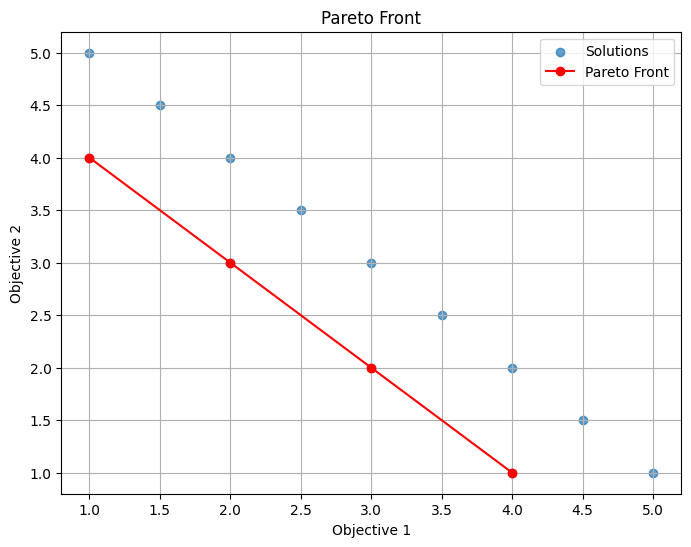

In [29]:
# Sort Pareto front for plotting
pareto_front = pareto_front[np.argsort(-pareto_front[:,0])]

plt.figure(figsize=(8, 6))
plt.scatter(-data[:, 0], -data[:, 1], label='Solutions', alpha=0.7)
plt.plot(-pareto_front[:, 0], -pareto_front[:, 1], marker='o', color='red', label='Pareto Front')

plt.xlabel('Objective 1')
plt.ylabel('Objective 2')
plt.title('Pareto Front')
plt.legend()
plt.grid(True)
plt.show()

In [76]:
# Generate random SPD matrix
import numpy as np
import torch

def random_spd_matrix(n, regularization=10):
    A = np.random.rand(n, n)
    return torch.tensor((np.dot(A, A.transpose()) + np.ones((n, n)) * regularization))

def random_spd_batch(batch_size, n):
    return torch.tensor(np.array([
        random_spd_matrix(n) for i in range(batch_size)
    ])).float()

device = 'cpu'

# Generate random binary mask
def generate_random_binary_mask(shape, probability=0.5, device='cpu'):
  """
  Generates a random binary mask tensor.

  Args:
    shape: The desired shape of the mask (tuple or list).
    probability: The probability of an element being 1 (float between 0 and 1).
    device: The device to create the tensor on ('cpu' or 'cuda').

  Returns:
    A binary mask tensor of the specified shape.
  """
  if not 0 <= probability <= 1:
    raise ValueError("Probability must be between 0 and 1")

  random_tensor = torch.rand(shape, device=device)
  binary_mask = (random_tensor < probability).int()
  return binary_mask

spd_batch = random_spd_batch(4, 3).to(device).float().reshape(2, 2, 3, 3)
binary_mask = torch.tensor([[True, False], [False, True]]).to(device)
spd_matrix = torch.zeros(3, 3).to(device)
print(spd_batch.shape, binary_mask.shape, spd_matrix.shape)

torch.Size([2, 2, 3, 3]) torch.Size([2, 2]) torch.Size([3, 3])


In [77]:
print(spd_batch)

tensor([[[[11.3661, 11.0088, 10.7394],
          [11.0088, 10.7617, 10.4839],
          [10.7394, 10.4839, 10.6832]],

         [[11.3035, 10.5981, 10.1820],
          [10.5981, 10.4894, 10.2274],
          [10.1820, 10.2274, 10.3701]]],


        [[[10.3256, 10.2080, 10.3696],
          [10.2080, 10.4852, 10.2311],
          [10.3696, 10.2311, 10.4292]],

         [[11.5719, 10.6478, 11.1390],
          [10.6478, 10.4872, 10.8150],
          [11.1390, 10.8150, 11.3715]]]])


In [78]:
print(spd_matrix)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [79]:
spd_batch[binary_mask] = spd_matrix
print(binary_mask)
print(f"spd_batch[binary_mask].shape: {spd_batch[binary_mask].shape}")

tensor([[ True, False],
        [False,  True]])
spd_batch[binary_mask].shape: torch.Size([2, 3, 3])


In [80]:
print(spd_batch.shape)
print(spd_batch)

torch.Size([2, 2, 3, 3])
tensor([[[[ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000]],

         [[11.3035, 10.5981, 10.1820],
          [10.5981, 10.4894, 10.2274],
          [10.1820, 10.2274, 10.3701]]],


        [[[10.3256, 10.2080, 10.3696],
          [10.2080, 10.4852, 10.2311],
          [10.3696, 10.2311, 10.4292]],

         [[ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000]]]])


In [4]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import WeightedRandomSampler
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt
import random
import os
import math
from Datasets.datasetTUEV import WaveletTUEVDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc, f1_score, cohen_kappa_score
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad
from scipy import signal
from scipy.fft import fft, fftfreq

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [5]:
print("*" * 50)
finetune_train_dataset = WaveletTUEVDataset(root="/home/hice1/mchen439/scratch/TUEV/train", frac=1.0, split="train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_test_dataset = WaveletTUEVDataset(root="/home/hice1/mchen439/scratch/TUEV/eval", frac=1.0, split="eval")
print("Dataset Loaded. Length of Test Dataset: ", len(finetune_test_dataset))

**************************************************
Loading 83932 folders


100%|██████████| 83932/83932 [03:42<00:00, 377.79it/s]


Dataset Loaded. Length of Train Dataset:  83932
Loading 29421 folders


100%|██████████| 29421/29421 [01:20<00:00, 367.53it/s]

Dataset Loaded. Length of Test Dataset:  29421


In [6]:
label_to_class = {
    0: 'spsw',
    1: 'gped',
    2: 'pled',
    3: 'eyem',
    4: 'artf',
    5: 'bckg',
}

In [11]:
def plot_event(band_input, class_idx):
    fig, ax = plt.subplots(5, figsize=(6, 5))
    for idx, (band, data) in enumerate(band_input.items()):
        data_small = data[:, data.shape[1] * 15 // 32:data.shape[1] * 17 // 16]
        ax[idx].plot(data_small)
        ax[idx].xaxis.set_visible(False)
        ax[idx].set_title(f"Original: {data.shape} Shape: {data_small.shape}")
    fig.suptitle(f"Class: {class_idx}")
    plt.tight_layout()
    plt.show()

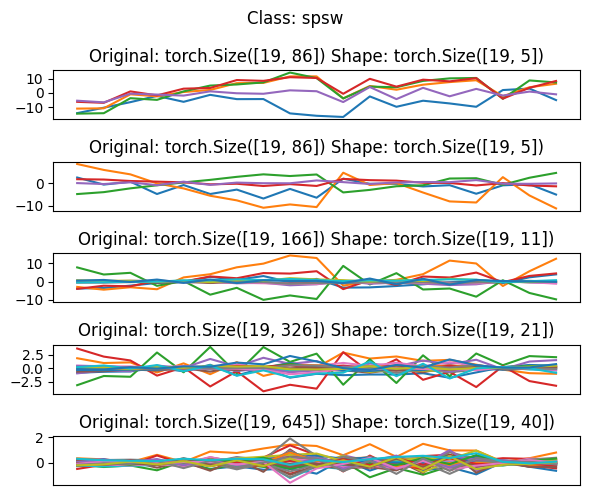

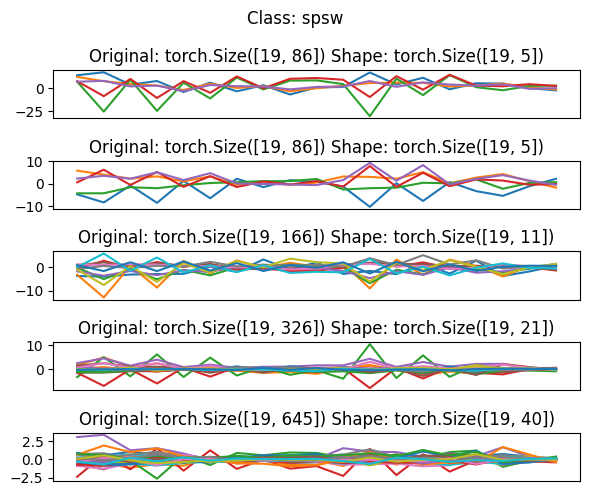

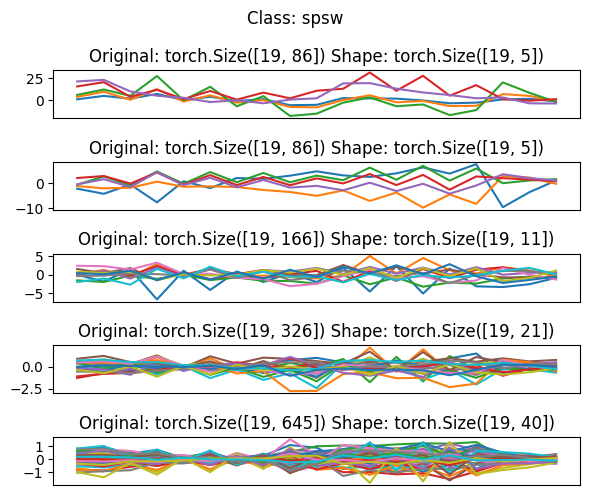

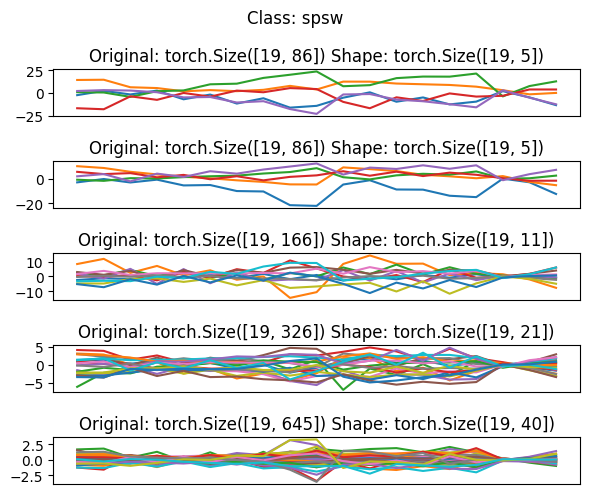

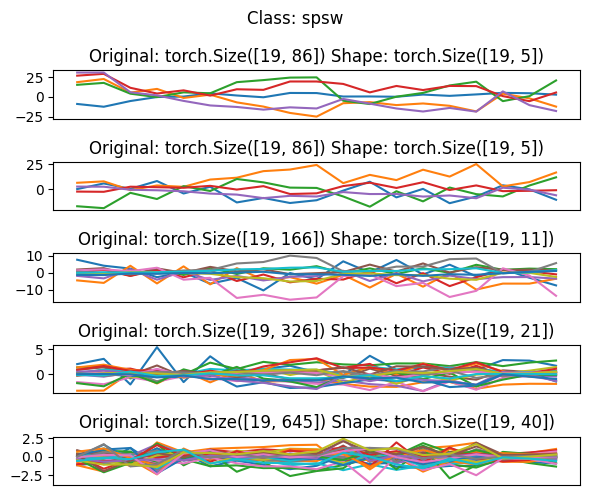

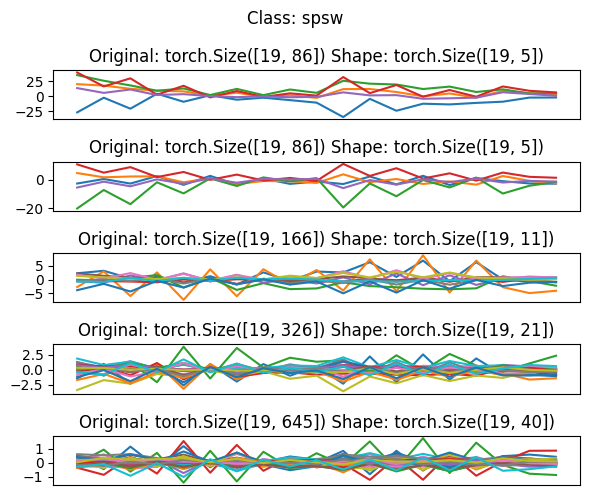

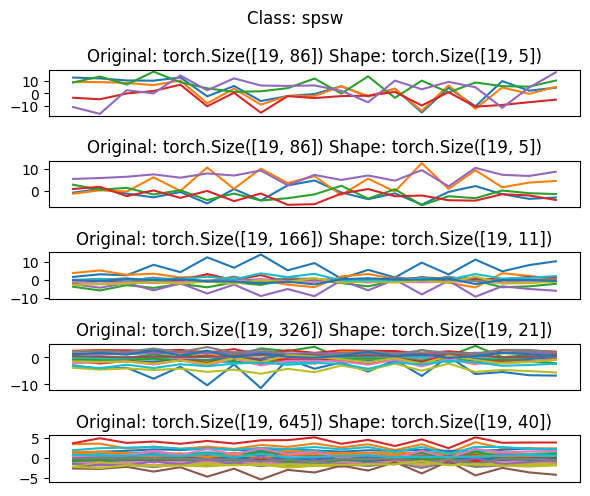

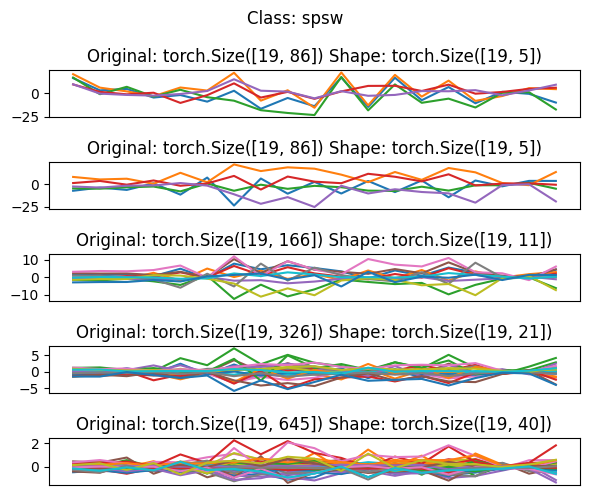

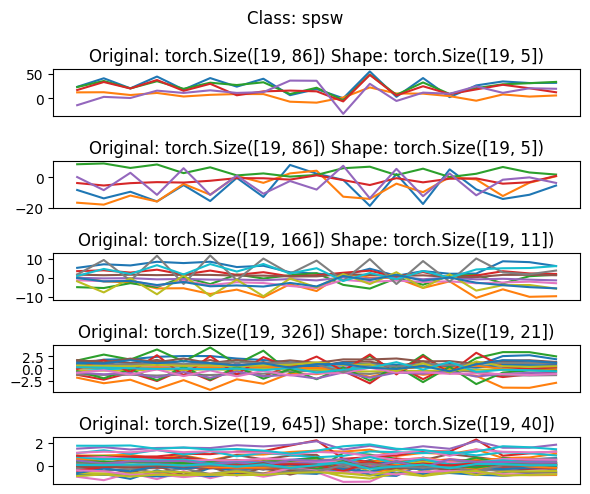

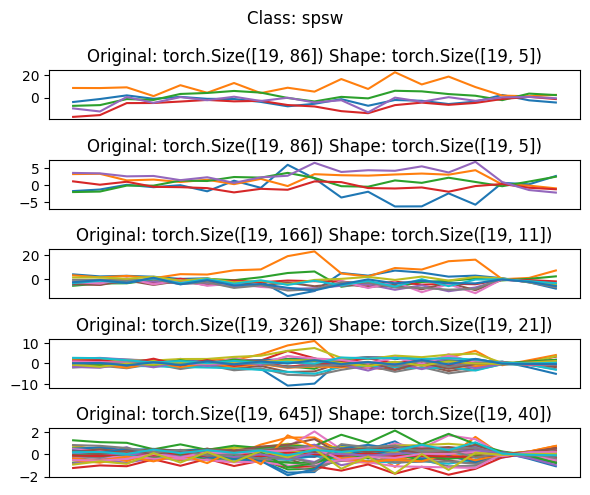

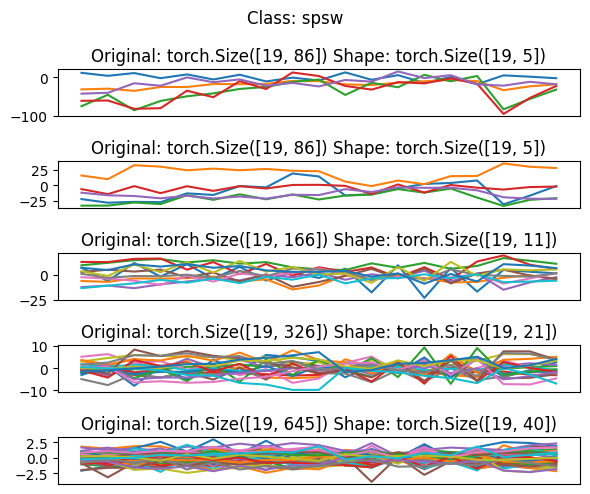

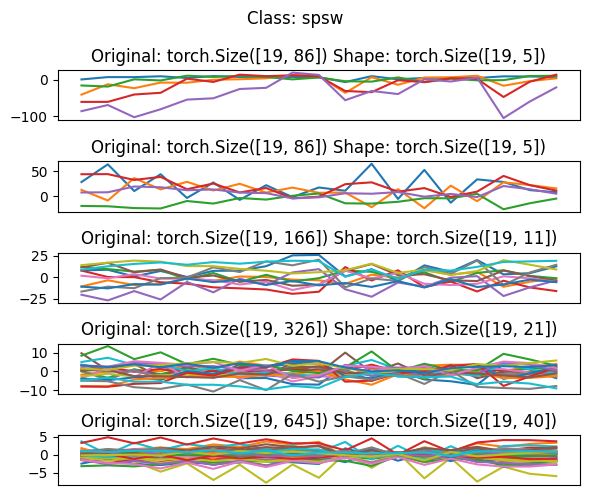

In [12]:
for i in range(1600):
    label = finetune_train_dataset[i]['graph'].y.item()
    #print(i, label_to_class[label], finetune_train_dataset[i]['delta'].shape)
    if label == 0:
        input_data = {
            'delta': finetune_train_dataset[i]['delta'],
            'theta': finetune_train_dataset[i]['theta'],
            'alpha': finetune_train_dataset[i]['alpha'],
            'beta':  finetune_train_dataset[i]['beta'],
            'gamma': finetune_train_dataset[i]['gamma'],
        }
        plot_event(input_data, label_to_class[label])

In [20]:
import numpy as np
import seaborn as sns

In [ ]:
results = { 
	'large_0.2': {
		'balanced_acc': [0.52048, 0.507415, 0.505774, 0.514233, 0.520274],
		'cohens kappa': [0.469191, 0.49508, 0.4895, 0.49180, 0.50627],
		'f1': [0.71687, 0.73897, 0.73552, 0.73557, 0.7452]
	},

	'large_0.4': {
		'balanced_acc': [0.5063, 0.51418, 0.5067, 0.49526, 0.5145],
		'cohens kappa': [0.4311, 0.4565, 0.4928, 0.4622, 0.47272],
		'f1': [0.6948, 0.7132, 0.7381, 0.7189, 0.72008],
	},

	'large_0.6': {
		'balanced_acc': [0.5345, 0.49474, 0.5197, 0.5559, 0.5415],
		'cohens kappa': [0.5079, 0.44315, 0.49703, 0.5481, 0.5046],
		'f1': [0.7438, 0.7095, 0.72248, 0.7461, 0.7614],
	},

	'large_0.8': {
		'balanced_acc': [0.5406, 0.53011, 0.51069, 0.524190, 0.52721],
		'cohens kappa': [0.5341, 0.72200, 0.47768, 0.545728, 0.47551],
		'f1': 			[0.7518, 0.46831, 0.72643, 0.759216, 0.72333],
	},

	'small_0.2': {
		'balanced_acc': [0.45751, 0.47144, 0.5061, 0.4831, 0.45726],
		'cohens kappa': [0.457001, 0.4988, 0.43635, 0.42358, 0.4275],
		'f1': 			[0.70346, 0.70733, 0.73524, 0.7139, 0.700039],
	},

	'small_0.4': {
		'balanced_acc': [0.4963, 0.48059, 0.51107, 0.484116, 0.4918256],
		'cohens kappa': [0.4154, 0.44766, 0.5056, 0.4603, 0.459005],
		'f1': [0.69253, 0.7114, 0.7196, 0.71959, 0.72128],
	},

	'small_0.6': {
		'balanced_acc': [0.4776, 0.4899, 0.4919, 0.4978, 0.5002],
		'cohens kappa': [0.4260, 0.4234, 0.4021, 0.4826, 0.4321],
		'f1': [0.6935, 0.6958, 0.6805, 0.73098, 0.7006],
	},
	'small_0.8': {
		'balanced_acc': [0.56391, 0.51876, 0.544958, 0.5489901, 0.5542680108871555],
		'cohens kappa': [0.50906, 0.45511, 0.4759, 0.51668, 0.553820978],
		'f1': 			[0.73771, 0.711240, 0.72490, 0.748380346,  0.7175896231],
	}
}

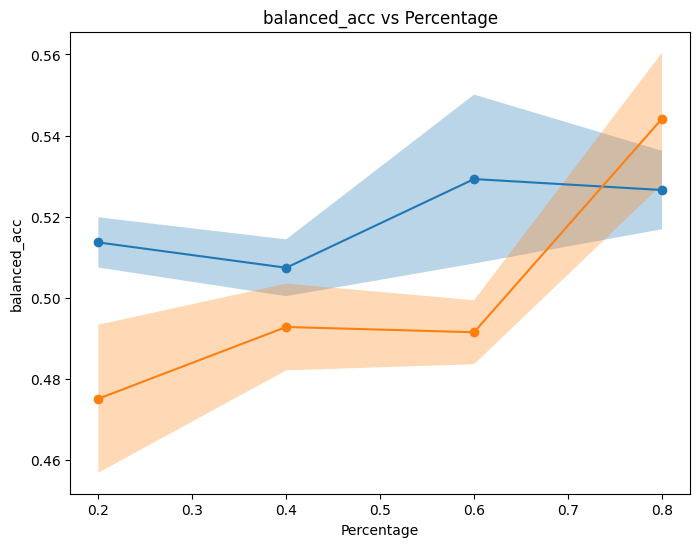

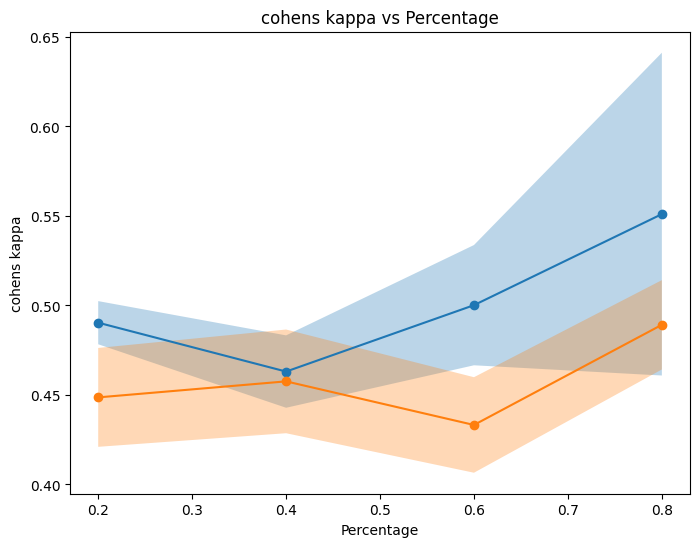

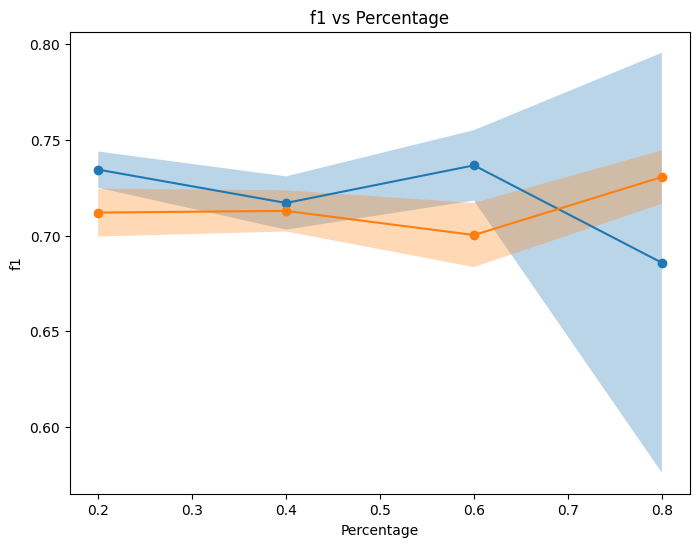

In [31]:
# For each metric, we plot curves for each model size ("large" and "small")
# where x is the percentage (the second part of the key, e.g., 0.2, 0.4, 0.6)
# and y is the mean value of the metric with error bars for the standard deviation.

# Get the list of metrics from one configuration (assumes all configs use the same keys)
metric_keys = list(results[next(iter(results))].keys())
model_sizes = ['large', 'small']

for metric_name in metric_keys:
	plt.figure(figsize=(8, 6))
	for size in model_sizes:
		x_vals = []
		mean_vals = []
		std_vals = []
		# Loop through each configuration in results
		for config, metric_dict in results.items():
			if config.startswith(size):
				# The key is like "large_0.2"; extract the percentage part
				_, perc_str = config.split('_')
				x_vals.append(float(perc_str))
				vals = np.array(metric_dict[metric_name])
				mean_vals.append(vals.mean())
				std_vals.append(vals.std())
		# Sort by percentage values
		sorter = np.argsort(x_vals)
		x_vals = np.array(x_vals)[sorter]
		mean_vals = np.array(mean_vals)[sorter]
		std_vals = np.array(std_vals)[sorter]
		# Plot the mean curve
		plt.ylabel(metric_name)
		plt.plot(x_vals, mean_vals, marker='o', label=f"{size}")
		
		# Fill between mean ± std
		plt.fill_between(x_vals, mean_vals - std_vals, mean_vals + std_vals, alpha=0.3)
		plt.title(f"{metric_name} vs Percentage")
		plt.xlabel("Percentage")

In [ ]:
for metric in ['balanced_acc', 'cohens kappa', 'f1']:
	for model in results.keys():
		plt.plot(results[model][metric].mean(), marker='o', linestyle='-', label=f"{k} - {metric}")

	plt.xlabel('Dataset Size')
	plt.ylabel(f'{metric} Value')
	plt.grid(True)
	plt.legend()
	plt.show()





large_0.2: balanced_acc: 0.5136 +/- 0.0062
large_0.4: balanced_acc: 0.5074 +/- 0.0070
large_0.6: balanced_acc: 0.5280 +/- 0.0193
small_0.2: balanced_acc: 0.4751 +/- 0.0183
small_0.4: balanced_acc: 0.4928 +/- 0.0107
small_0.6: balanced_acc: 0.4915 +/- 0.0079
large_0.2: cohens kappa: 0.4904 +/- 0.0121
large_0.4: cohens kappa: 0.4631 +/- 0.0202
large_0.6: cohens kappa: 0.4964 +/- 0.0287
small_0.2: cohens kappa: 0.4486 +/- 0.0276
small_0.4: cohens kappa: 0.4576 +/- 0.0290
small_0.6: cohens kappa: 0.4332 +/- 0.0267
large_0.2: f1: 0.7344 +/- 0.0095
large_0.4: f1: 0.7170 +/- 0.0139
large_0.6: f1: 0.7320 +/- 0.0140
small_0.2: f1: 0.7120 +/- 0.0125
small_0.4: f1: 0.7129 +/- 0.0107
small_0.6: f1: 0.7003 +/- 0.0167


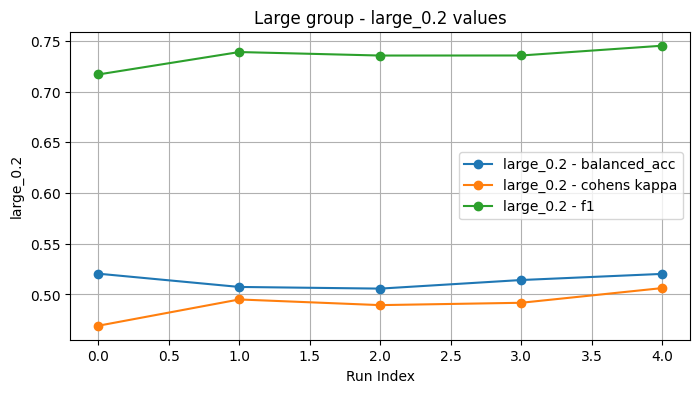

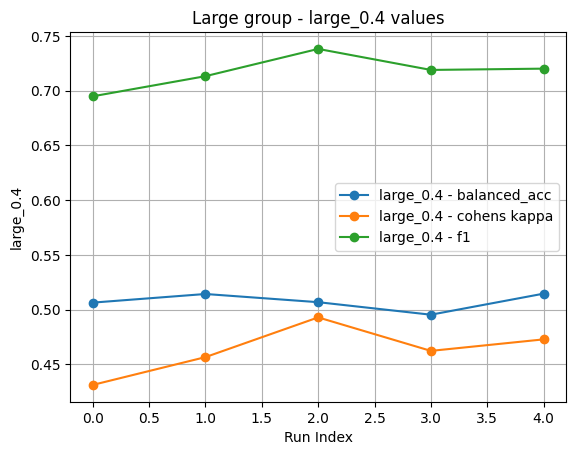

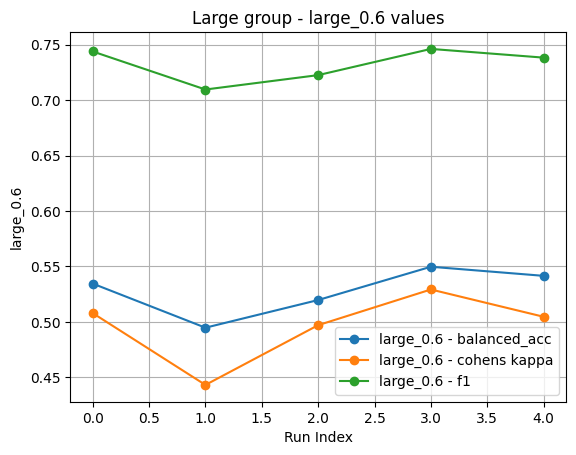

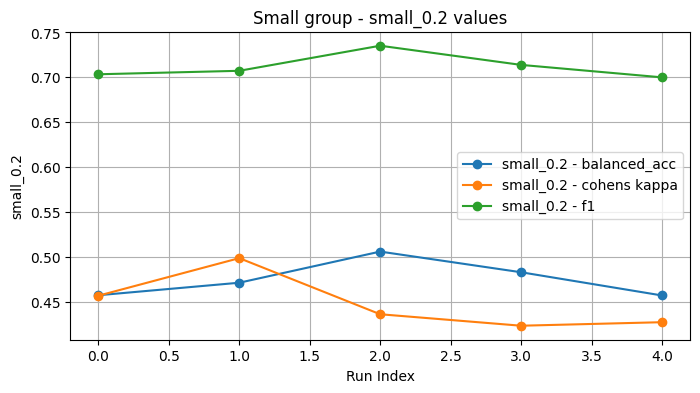

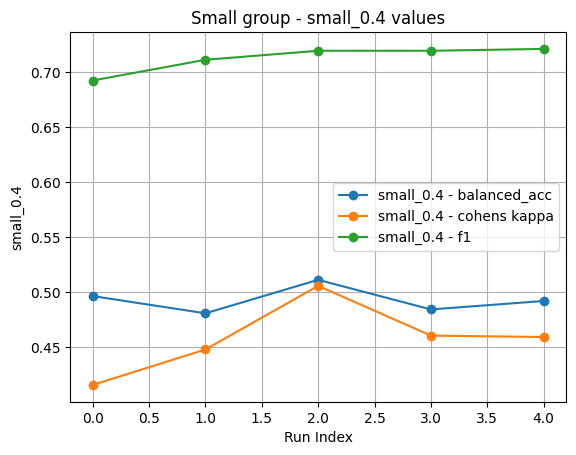

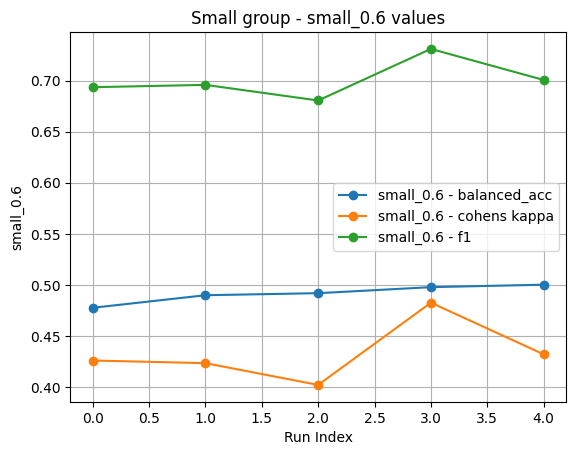

In [18]:
# Group the results based on keys starting with "large" or "small"
groups = {"large": {}, "small": {}}
for k, v in results.items():
	if k.startswith("large"):
		groups["large"][k] = v
	elif k.startswith("small"):
		groups["small"][k] = v

# Plot each group in a separate figure
for group_name, group in groups.items():
	plt.figure(figsize=(8, 4))
	for k, v in group.items():
		for metric, values in v.items():
			# Plot each metric separately
			plt.plot(values, marker='o', linestyle='-', label=f"{k} - {metric}")
		plt.title(f"{group_name.capitalize()} group - {k} values")
		plt.xlabel("Run Index")
		plt.ylabel(k)
		plt.grid(True)
		plt.legend()
		plt.show()

In [5]:
from Datasets.datasetPretrain import WaveletPretrainDataset
from torch_geometric.loader import DataLoader
dataset = WaveletPretrainDataset(root="/storage/ice1/shared/bmed6780/mip_group_6/ef/TUH-128Hz", frac=0.001)

Loading 13 subjects


100%|██████████| 13/13 [00:00<00:00, 22.15it/s]


In [32]:
loader = DataLoader(dataset, batch_size=1, num_workers=32, shuffle=True, persistent_workers=True, pin_memory=True)

In [33]:
batch = next(iter(loader))
print(batch.keys())

dict_keys(['graph', 'subject_name', 'subject_idx', 'delta', 'theta', 'alpha', 'beta', 'gamma'])


In [34]:
print(batch['graph'])

DataBatch(edge_index=[2, 361], edge_attr=[361, 1], pos=[19, 3], batch=[19], ptr=[2])


In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import mne

In [40]:
# Load 10-20 standard montage
montage = mne.channels.make_standard_montage('standard_1005')
positions = montage.get_positions()['ch_pos']

# Normalize keys to uppercase for matching
positions_upper = {k.upper(): v for k, v in positions.items()}

channels_to_use = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4',
		    'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6',
			  'Fz', 'Cz', 'Pz']

# Filter positions for available channels (case-insensitive match)
valid_channels = [ch.upper() for ch in channels_to_use if ch.upper() in positions_upper] 
print(f"Valid Channels: {valid_channels}", len(valid_channels))

pos = {ch: (positions_upper[ch][0], positions_upper[ch][1]) for ch in valid_channels}

# Normalize to unit circle for consistent layout
xy = np.array(list(pos.values()))
xy -= xy.mean(axis=0)
xy /= np.linalg.norm(xy, axis=1).max()
pos = {ch: (x, y) for ch, (x, y) in zip(valid_channels, xy)}

# Create graph
G = nx.Graph()
G.add_nodes_from(valid_channels)

# Random edge weights (simulate connectivity)
np.random.seed(42)
for i, ch1 in enumerate(valid_channels):
    for j, ch2 in enumerate(valid_channels):
        if ch1 == 'CZ':
            weight = batch['graph'].edge_attr[i*19 + j].item()
            G.add_edge(ch1, ch2, weight=weight)

Valid Channels: ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ'] 19


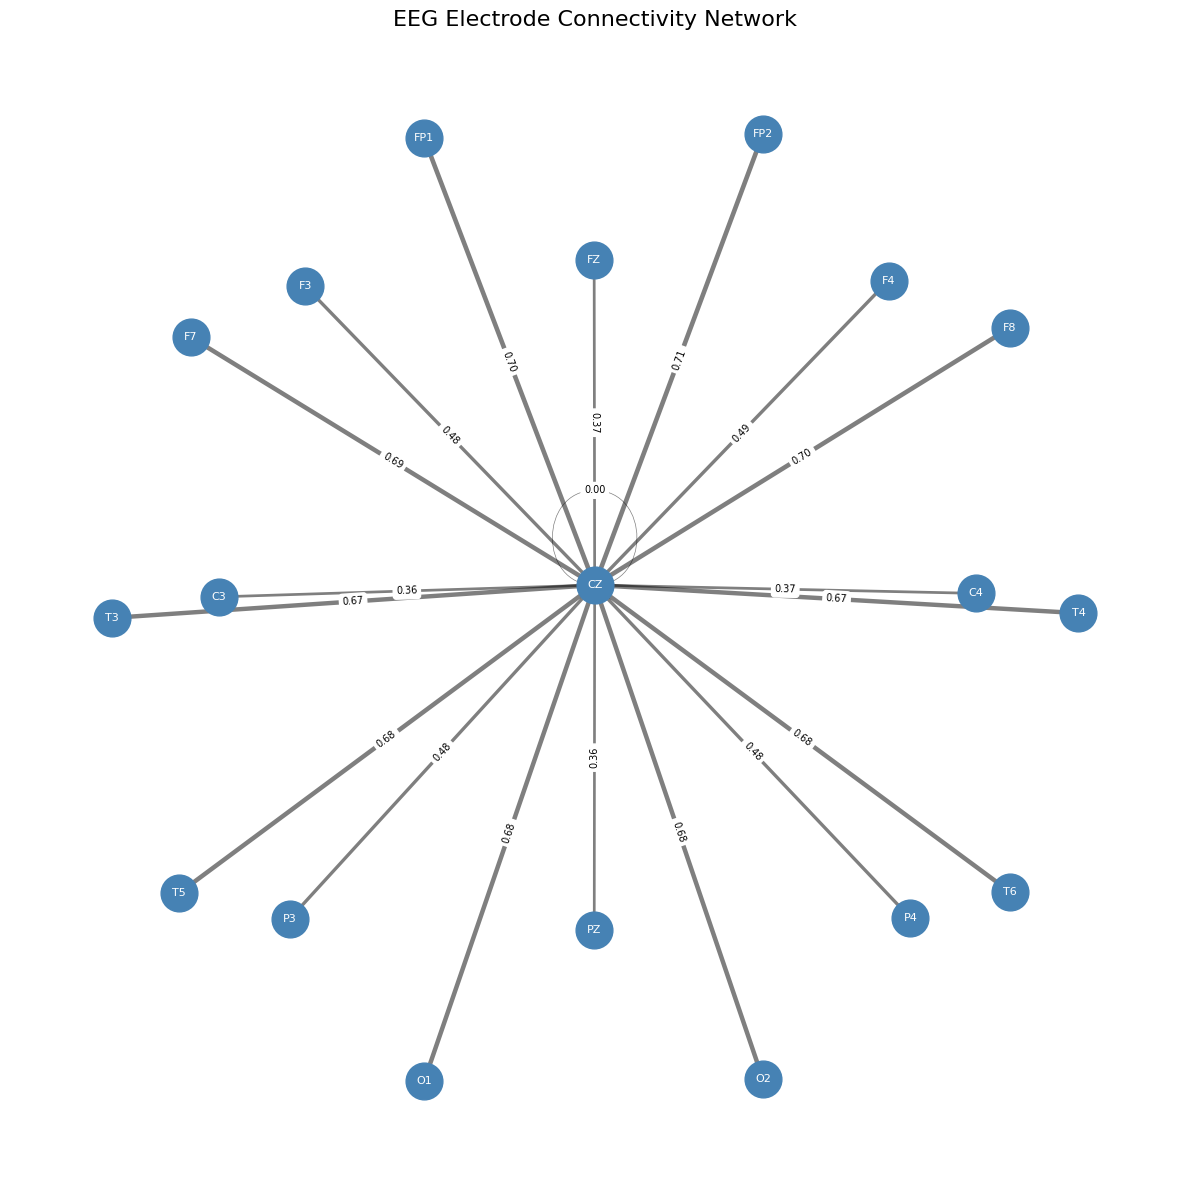

In [43]:
# Draw graph
plt.figure(figsize=(12, 12))
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=700)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(u, v) for u, v, d in edges],
    width=[4 * d['weight'] + 0.5 for (_, _, d) in edges],
    edge_color='black',
    alpha=0.5
)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')

plt.axis('off')
plt.title("EEG Electrode Connectivity Network", fontsize=16)
plt.tight_layout()
plt.show()

In [1]:
import mne

In [4]:
raw = mne.io.read_raw_edf("/home/azureuser/mycontainer/CHB-MIT/physionet.org/files/chbmit/1.0.0/chb14/chb14_14.edf", verbose=False)

/tmp/ipykernel_173376/3121974662.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'-', 'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf("/home/azureuser/mycontainer/CHB-MIT/physionet.org/files/chbmit/1.0.0/chb14/chb14_14.edf", verbose=False)
/tmp/ipykernel_173376/3121974662.py:1: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf("/home/azureuser/mycontainer/CHB-MIT/physionet.org/files/chbmit/1.0.0/chb14/chb14_14.edf", verbose=False)


In [5]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 28 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2071-03-22 03:36:16 UTC
 nchan: 28
 projs: []
 sfreq: 256.0 Hz
 subject_info: 1 item (dict)
>
